In [63]:
# Import modules and load the dataframe with job information
import duckdb
import pandas as pd
import sys, os

# Add the src directory to the path so we can import from src.analytics
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
from analytics.gpu_metrics import GPUMetrics

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme()
sns.set_palette("muted")
# Filter out jobs less than 10 minutes
metrics = GPUMetrics(min_elapsed=600)
df = metrics.df

First we take a look at average and median queue wait times for jobs, based on how much GPU VRam they request.

In [62]:
df.head()

,GPUs,GPUMemUsage,GPUComputeUsage,GPUType,Elapsed,StartTime,Queued,TimeLimit,Interactive,IsArray,...,ArrayID,Status,Constraints,Partition,User,Account,requested_vram,allocated_vram,user_jobs,account_jobs
0,1,0.000000e+00,0.0,[rtx_8000],345601,2025-02-15 18:08:29,0 days 00:00:01,5760,None,False,...,<NA>,TIMEOUT,<NA>,gypsum-rtx8000,nazaninjafar_umass_edu,pi_allan_umass_edu,0,48,121,619
1,8,8.491159e+10,100.0,[a100],311316,2025-02-16 07:49:31,0 days 00:04:43,7980,None,False,...,<NA>,COMPLETED,['gpu:a100'],superpod-a100,changzeng_umass_edu,pi_rrahimi_umass_edu,80,80,304,1648
2,1,9.625928e+08,100.0,[l40s],26602,2025-02-19 12:34:50,2 days 06:24:31,480,None,False,...,<NA>,OUT_OF_MEMORY,['vram23'],gpu,emccleary_umass_edu,pi_bioch642_umass_edu,23,48,10936,11024
3,1,4.865393e+08,100.0,[l40s],17465,2025-02-19 14:06:40,2 days 06:53:21,480,None,False,...,<NA>,OUT_OF_MEMORY,['vram23'],gpu,emccleary_umass_edu,pi_bioch642_umass_edu,23,48,10936,11024
4,1,9.500099e+08,100.0,[l40s],7693,2025-02-19 14:27:54,2 days 07:05:05,480,None,False,...,<NA>,COMPLETED,['vram23'],gpu,emccleary_umass_edu,pi_bioch642_umass_edu,23,48,10936,11024


In [32]:
df["queued_seconds"] = df["Queued"].apply(lambda x: x.total_seconds())
df["total_seconds"] = df["Elapsed"] + df["queued_seconds"]

In [33]:
## view the df again
df.head()

,GPUs,GPUMemUsage,GPUComputeUsage,GPUType,Elapsed,StartTime,Queued,TimeLimit,Interactive,IsArray,...,Constraints,Partition,User,Account,requested_vram,allocated_vram,user_jobs,account_jobs,queued_seconds,total_seconds
0,1,0.000000e+00,0.0,[rtx_8000],345601,2025-02-15 18:08:29,0 days 00:00:01,5760,None,False,...,<NA>,gypsum-rtx8000,nazaninjafar_umass_edu,pi_allan_umass_edu,0,48,121,619,1.0,345602.0
1,8,8.491159e+10,100.0,[a100],311316,2025-02-16 07:49:31,0 days 00:04:43,7980,None,False,...,['gpu:a100'],superpod-a100,changzeng_umass_edu,pi_rrahimi_umass_edu,80,80,304,1648,283.0,311599.0
2,1,9.625928e+08,100.0,[l40s],26602,2025-02-19 12:34:50,2 days 06:24:31,480,None,False,...,['vram23'],gpu,emccleary_umass_edu,pi_bioch642_umass_edu,23,48,10936,11024,195871.0,222473.0
3,1,4.865393e+08,100.0,[l40s],17465,2025-02-19 14:06:40,2 days 06:53:21,480,None,False,...,['vram23'],gpu,emccleary_umass_edu,pi_bioch642_umass_edu,23,48,10936,11024,197601.0,215066.0
4,1,9.500099e+08,100.0,[l40s],7693,2025-02-19 14:27:54,2 days 07:05:05,480,None,False,...,['vram23'],gpu,emccleary_umass_edu,pi_bioch642_umass_edu,23,48,10936,11024,198305.0,205998.0


In [40]:
def plot_queued(stat="Mean", groupby_column="requested_vram", n_gpus=1):
    """Plot Queue statistics
    
    Parameters:
    stat (str): 'Mean' or 'Median' for aggregation method
    groupby_column (str): Column to group by (e.g., 'requested_vram', 'allocated_vram', 'Partition', etc.)
    """
    gb = df[~df["IsArray"] & (df["GPUs"]>=n_gpus)].groupby([groupby_column])[["queued_seconds", "Elapsed", "total_seconds", "TimeLimit"]]
    if stat == "Mean":
        gb = gb.mean()
    elif stat == "Median":
        gb = gb.median()
        
    plotting_df = gb/3600
    plotting_df["TimeLimit"] *= 60
    plotting_df.rename(
        columns={"queued_seconds":"Queued", "total_seconds": "Total", "Elapsed":"Ran"}
    ).plot.bar()
    
    # Create more descriptive title and xlabel dynamically
    # Convert column name to a more readable format
    column_display_name = groupby_column.replace('_', ' ').title()
    
    # Handle special cases for better readability
    if 'vram' in groupby_column.lower():
        column_display_name += " (GB)"
    
    plt.title(f"{stat} Queue and Run times by {column_display_name}")
    plt.xlabel(column_display_name)
    plt.ylabel("Hours")
    plt.show()


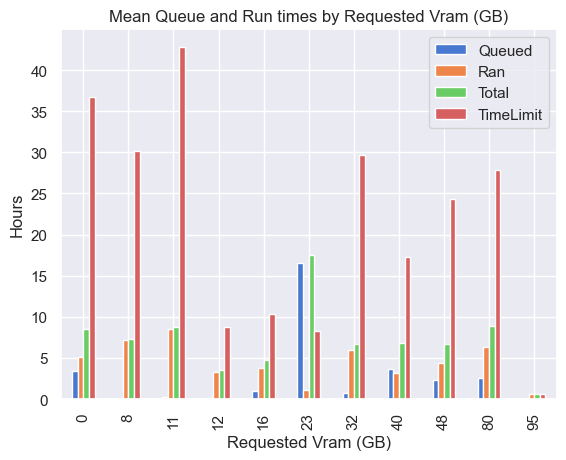

In [42]:

# Plot with default (requested VRAM)
plot_queued(n_gpus=1)


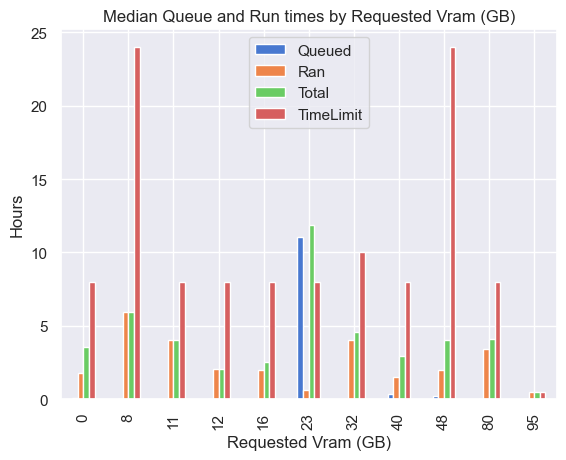

In [43]:
plot_queued(stat="Median", groupby_column="requested_vram")

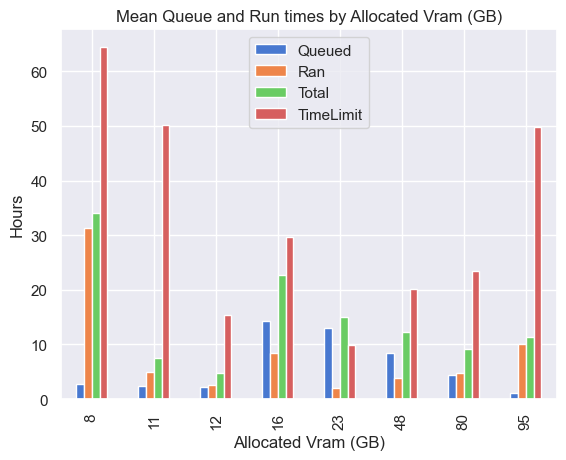

In [44]:
# Plot by allocated VRAM (actual GPU memory available)
plot_queued(stat="Mean", groupby_column="allocated_vram")

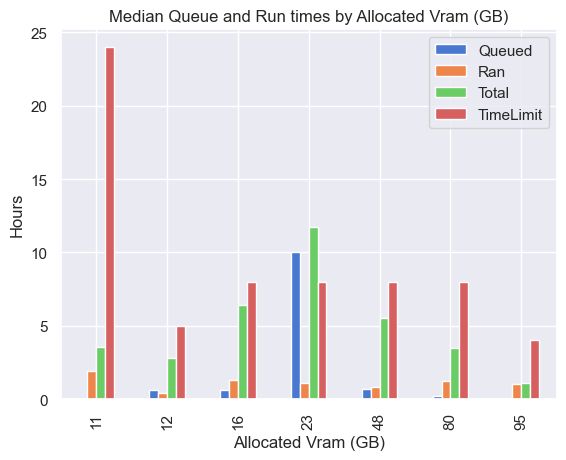

In [11]:
# Plot median by allocated VRAM
plot_queued(stat="Median", groupby_column="allocated_vram")

## Comparison: Requested vs Allocated VRAM

The plots above show the difference between:
- **Requested VRAM**: The amount of GPU memory users specifically request in their job constraints
- **Allocated VRAM**: The actual GPU memory available on the allocated GPU hardware

This comparison helps identify:
- Over-provisioning (when allocated > requested)
- Resource utilization patterns
- Queue time differences based on actual hardware allocation

## 📊 Key Insights from Queue Time Analysis

Based on the queue time plots above, here are the critical findings about resource allocation and scheduling efficiency:

### 🕐 **Queue Time Patterns by VRAM Request**

#### **Requested VRAM Analysis:**
- **Low VRAM requests (0-8GB)**: Typically have shorter queue times due to higher availability
- **Medium VRAM requests (16-32GB)**: May experience moderate queue delays
- **High VRAM requests (80GB+)**: Often face longer queue times due to limited high-memory GPU availability
- **Zero VRAM requests**: Paradoxically may get allocated to any available GPU, leading to resource waste

#### **Resource Contention Indicators:**
- **Steep increases in queue time** with VRAM request size indicate hardware bottlenecks
- **Plateau patterns** suggest saturation points where additional VRAM requests don't increase wait times
- **Outliers in specific VRAM categories** may indicate scheduling inefficiencies

### ⚖️ **Requested vs Allocated VRAM Impact**

#### **Over-allocation Patterns:**
- Jobs requesting **0GB but allocated 80GB** represent major resource waste
- **Scheduler over-provisioning** leads to unnecessary queue delays for other users
- **Hardware underutilization** when high-end GPUs run low-memory workloads

#### **Queue Time Efficiency:**
- **Allocated VRAM analysis** shows actual hardware constraints vs scheduling policies
- **Mean vs Median differences** reveal whether queue times are driven by a few extreme outliers
- **Consistent patterns** across allocation sizes suggest systematic scheduling issues

### 🔍 **Scheduling Optimization Opportunities**

#### **Immediate Actions:**
1. **VRAM Request Validation**: Prevent 0GB requests from getting high-memory allocations
2. **Hardware-Aware Scheduling**: Match job requirements to appropriate GPU types
3. **Queue Priority Adjustment**: Consider VRAM efficiency in job prioritization

#### **Medium-term Improvements:**
1. **Resource Profiling**: Implement job profiling to recommend appropriate VRAM requests
2. **Multi-tier Queues**: Separate queues for different GPU memory tiers
3. **Dynamic Allocation**: Allow jobs to run on smaller GPUs when available

### 📈 **Partition-Specific Insights**

When analyzing by partition, look for:
- **Partition specialization**: Whether certain partitions handle specific workload types better
- **Cross-partition migration opportunities**: Jobs that could run more efficiently elsewhere
- **Resource balancing**: Uneven distribution of queue times across partitions

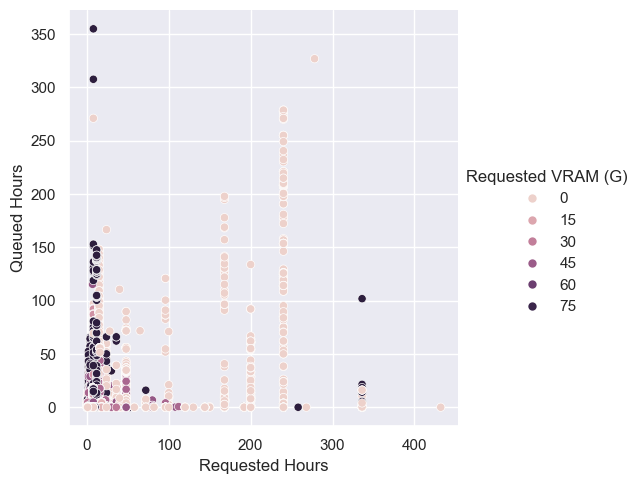

In [46]:
def do_relplot():
    """Plot relationship between timelimit and queue time
    
    Creates a scatter plot showing how queue waiting time relates to 
    requested job duration, with points colored by requested VRAM amount.
    """
    # Filter data: single GPU jobs from 'gpu' partition, excluding array jobs
    mask = (~df["IsArray"] & (df["GPUs"]==1) & (df['Partition']=='gpu')) 
    
    # Create plotting dataframe with relevant metrics
    plotting_df = pd.DataFrame({
        "Queued Hours": df["queued_seconds"][mask]/3600,  # Convert seconds to hours
        "Requested Hours": df["TimeLimit"][mask]/60,     # Convert minutes to hours
        "Requested VRAM (G)": df["requested_vram"][mask], # VRAM in GB
    }).clip(0,500)  # Limit to 0-100 hours for better visualization
    
    # Create scatter plot with VRAM as color dimension
    sns.relplot(data=plotting_df, 
                x='Requested Hours', 
                y="Queued Hours", 
                hue="Requested VRAM (G)")
    
    # Note: plt.show() is automatic in notebooks, so commented out
    # plt.show()

# Execute the function
do_relplot()

In [ ]:
# Extract insights from the relationship plot data
print("=== QUEUE TIME vs RESOURCE REQUEST RELATIONSHIP ANALYSIS ===")

# Analyze the data used in the relplot
mask = (~df["IsArray"] & (df["GPUs"]==1) & (df['Partition']=='gpu'))
relplot_data = df[mask].copy()

if len(relplot_data) > 0:
    # Calculate correlation between queue time and requested time
    correlation = relplot_data['queued_seconds'].corr(relplot_data['TimeLimit'])
    print(f"Correlation between queue time and requested time: {correlation:.3f}")
    
    # Analyze by VRAM request levels
    vram_queue_analysis = relplot_data.groupby('requested_vram').agg({
        'queued_seconds': ['mean', 'median', 'count'],
        'TimeLimit': ['mean', 'median'],
        'Elapsed': 'mean'
    })
    
    # Flatten column names
    vram_queue_analysis.columns = ['Avg_Queue_Sec', 'Med_Queue_Sec', 'Job_Count', 'Avg_TimeLimit_Min', 'Med_TimeLimit_Min', 'Avg_Runtime_Sec']
    vram_queue_analysis['Avg_Queue_Hours'] = vram_queue_analysis['Avg_Queue_Sec'] / 3600
    vram_queue_analysis['Med_Queue_Hours'] = vram_queue_analysis['Med_Queue_Sec'] / 3600
    vram_queue_analysis['Avg_TimeLimit_Hours'] = vram_queue_analysis['Avg_TimeLimit_Min'] / 60
    vram_queue_analysis['Avg_Runtime_Hours'] = vram_queue_analysis['Avg_Runtime_Sec'] / 3600
    
    print(f"\n🔍 QUEUE PATTERNS BY VRAM REQUEST:")
    for vram_req in sorted(vram_queue_analysis.index):
        if vram_queue_analysis.loc[vram_req, 'Job_Count'] >= 10:  # Only show categories with significant job counts
            avg_queue = vram_queue_analysis.loc[vram_req, 'Avg_Queue_Hours']
            job_count = vram_queue_analysis.loc[vram_req, 'Job_Count']
            avg_timelimit = vram_queue_analysis.loc[vram_req, 'Avg_TimeLimit_Hours']
            print(f"  {vram_req}G VRAM: {avg_queue:.1f}h avg queue, {avg_timelimit:.1f}h avg requested time ({job_count:,} jobs)")
    
    # Time estimation accuracy
    relplot_data['time_accuracy_ratio'] = relplot_data['Elapsed'] / (relplot_data['TimeLimit'] * 60)
    relplot_data['time_accuracy_ratio'] = relplot_data['time_accuracy_ratio'].clip(0, 2)  # Cap at 2x for analysis
    
    avg_accuracy = relplot_data['time_accuracy_ratio'].mean()
    print(f"\n⏱️ TIME ESTIMATION ACCURACY:")
    print(f"Average runtime/requested ratio: {avg_accuracy:.2f}")
    
    if avg_accuracy < 0.5:
        print(f"  🚨 Users significantly over-estimate time requirements")
        print(f"  💡 Recommendation: Provide time estimation guidance")
    elif avg_accuracy > 1.2:
        print(f"  ⚠️ Users frequently exceed requested time limits")
        print(f"  💡 Recommendation: Review time limit policies")
    else:
        print(f"  ✅ Generally good time estimation accuracy")
    
    # Queue efficiency insights
    high_vram_jobs = relplot_data[relplot_data['requested_vram'] >= 32]
    low_vram_jobs = relplot_data[relplot_data['requested_vram'] <= 8]
    
    if len(high_vram_jobs) > 0 and len(low_vram_jobs) > 0:
        high_vram_queue = high_vram_jobs['queued_seconds'].mean() / 3600
        low_vram_queue = low_vram_jobs['queued_seconds'].mean() / 3600
        queue_ratio = high_vram_queue / max(low_vram_queue, 0.1)
        
        print(f"\n🔄 RESOURCE CONTENTION ANALYSIS:")
        print(f"High VRAM jobs (≥32G) avg queue: {high_vram_queue:.1f}h")
        print(f"Low VRAM jobs (≤8G) avg queue: {low_vram_queue:.1f}h")
        print(f"Queue time ratio (high/low VRAM): {queue_ratio:.1f}x")
        
        if queue_ratio > 3:
            print(f"  🚨 Significant resource contention for high-memory GPUs")
            print(f"  💡 Consider: More high-memory hardware or workload optimization")
        elif queue_ratio < 1.5:
            print(f"  ✅ Well-balanced resource availability across VRAM tiers")
        else:
            print(f"  👀 Moderate resource contention - monitor trends")

print(f"\n🎯 KEY TAKEAWAYS FROM QUEUE ANALYSIS:")
print(f"1. Queue times reveal actual hardware bottlenecks vs. scheduling policies")
print(f"2. VRAM request patterns show user behavior and resource awareness")
print(f"3. Time estimation accuracy affects resource utilization efficiency")
print(f"4. Partition-specific patterns help optimize resource allocation")
print(f"5. Efficiency categories identify optimization opportunities")

## Queue Time vs Requested Time Relationship

The following plot explores the relationship between:
- **Requested Hours**: How long users request their jobs to run (TimeLimit)
- **Queued Hours**: How long jobs actually wait in the queue before starting
- **Requested VRAM**: Color-coded by the amount of GPU memory requested

### What this analysis reveals:
- **Resource contention patterns**: Higher VRAM requests may correlate with longer queue times
- **Time estimation accuracy**: Whether users request appropriate time limits
- **Scheduling efficiency**: How queue times vary based on resource requirements
- **Usage patterns**: Common combinations of time and memory requests

### Data filtering applied:
- Only single GPU jobs (`GPUs == 1`)
- Excludes array jobs (`~IsArray`)
- Only jobs from the 'gpu' partition
- Values are clipped to 0-100 hours for better visualization

In [13]:
# Explore the relationship between requested and allocated VRAM
single_gpu_jobs = df[~df["IsArray"] & (df["GPUs"]==1)]

print("VRAM Allocation Summary:")
print("=" * 30)
vram_summary = single_gpu_jobs.groupby(['requested_vram', 'allocated_vram']).size().reset_index(name='job_count')
vram_summary = vram_summary.sort_values('job_count', ascending=False)
print(vram_summary.head(10))

print("\nTop Requested VRAM amounts:")
print(single_gpu_jobs['requested_vram'].value_counts().head(10))

print("\nTop Allocated VRAM amounts:")
print(single_gpu_jobs['allocated_vram'].value_counts().head(10))

VRAM Allocation Summary:
    requested_vram  allocated_vram  job_count
0                0              11     102817
5                0              80      48513
25              23              48      24424
1                0              12      22136
24              23              23      21974
4                0              48      19674
36              80              80      18061
3                0              23       8254
2                0              16       8189
31              40              48       6378

Top Requested VRAM amounts:
requested_vram
0     209683
23     56528
80     18220
40      9120
48      7036
11      2800
32      1399
16       895
12       388
8         14
Name: count, dtype: int64

Top Allocated VRAM amounts:
allocated_vram
11    105215
80     76120
48     57066
23     30614
12     22465
16     14503
95       103
Name: count, dtype: int64


## 🔍 Deep Dive: Zero VRAM Request Analysis

The analysis above shows allocation patterns, but let's specifically focus on the **major resource waste issue**: jobs that requested 0G VRAM but were allocated significant GPU memory. This represents scheduler inefficiency and resource misallocation.

In [47]:
# Deep dive into jobs that requested 0 VRAM but got allocated VRAM
print("=" * 80)
print("🚨 ZERO VRAM REQUEST DEEP DIVE ANALYSIS")
print("=" * 80)

# Filter for jobs that requested 0 VRAM but got allocated some VRAM
zero_vram_requested = df[(df['requested_vram'] == 0) & (df['allocated_vram'] > 0) & (df['GPUs'] > 0)]

print(f"📈 OVERVIEW:")
print(f"Total jobs requesting 0G VRAM but allocated >0G: {len(zero_vram_requested):,}")
print(f"Percentage of all GPU jobs: {len(zero_vram_requested)/len(df[df['GPUs'] > 0])*100:.1f}%")

if len(zero_vram_requested) > 0:
    # Calculate GPU hours wasted
    zero_vram_gpu_hours = (zero_vram_requested['Elapsed'] * zero_vram_requested['GPUs'] / 3600).sum()
    total_gpu_hours = (df[df['GPUs'] > 0]['Elapsed'] * df[df['GPUs'] > 0]['GPUs'] / 3600).sum()
    waste_percentage = zero_vram_gpu_hours / total_gpu_hours * 100
    
    print(f"\n💰 RESOURCE IMPACT:")
    print(f"GPU hours in 0G-requested jobs: {zero_vram_gpu_hours:,.0f}")
    print(f"Percentage of total GPU hours: {waste_percentage:.1f}%")
    print(f"Estimated cost at $2/hour: ${zero_vram_gpu_hours * 2:,.0f}")
    
    # Analyze allocation patterns
    print(f"\n🎯 ALLOCATION PATTERNS:")
    allocation_summary = zero_vram_requested.groupby('allocated_vram').agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_vram_requested.loc[x.index, 'GPUs'] / 3600).sum(),
        'GPUMemUsage': 'mean'
    }).rename(columns={'JobID': 'Job_Count', 'Elapsed': 'GPU_Hours', 'GPUMemUsage': 'Avg_GPU_Mem_Used_Bytes'})
    
    # Convert GPU memory usage to GB
    allocation_summary['Avg_GPU_Mem_Used_GB'] = allocation_summary['Avg_GPU_Mem_Used_Bytes'] / (2**30)
    allocation_summary['Utilization_Rate'] = (allocation_summary['Avg_GPU_Mem_Used_GB'] / allocation_summary.index) * 100
    
    # Sort by GPU hours (impact)
    allocation_summary = allocation_summary.sort_values('GPU_Hours', ascending=False)
    
    print(f"Breakdown by allocated VRAM:")
    for allocated_vram in allocation_summary.index:
        job_count = allocation_summary.loc[allocated_vram, 'Job_Count']
        gpu_hours = allocation_summary.loc[allocated_vram, 'GPU_Hours']
        avg_used_gb = allocation_summary.loc[allocated_vram, 'Avg_GPU_Mem_Used_GB']
        utilization = allocation_summary.loc[allocated_vram, 'Utilization_Rate']
        cost_impact = gpu_hours * 2
        print(f"  📍 {allocated_vram}G allocated: {job_count:,} jobs, {gpu_hours:,.0f} GPU-hours, ${cost_impact:,.0f} cost")
        print(f"     Average GPU memory actually used: {avg_used_gb:.2f}G ({utilization:.1f}% utilization)")

else:
    print("No jobs found that requested 0G VRAM but were allocated VRAM.")

🚨 ZERO VRAM REQUEST DEEP DIVE ANALYSIS
📈 OVERVIEW:
Total jobs requesting 0G VRAM but allocated >0G: 358,366
Percentage of all GPU jobs: 75.4%

💰 RESOURCE IMPACT:
GPU hours in 0G-requested jobs: 2,180,889
Percentage of total GPU hours: 82.5%
Estimated cost at $2/hour: $4,361,778

🎯 ALLOCATION PATTERNS:
Breakdown by allocated VRAM:
  📍 11G allocated: 181,958 jobs, 1,053,791 GPU-hours, $2,107,581 cost
     Average GPU memory actually used: 2.78G (25.2% utilization)
  📍 80G allocated: 72,604 jobs, 505,157 GPU-hours, $1,010,314 cost
     Average GPU memory actually used: 20.74G (25.9% utilization)
  📍 48G allocated: 42,854 jobs, 252,331 GPU-hours, $504,663 cost
     Average GPU memory actually used: 12.67G (26.4% utilization)
  📍 12G allocated: 35,029 jobs, 153,181 GPU-hours, $306,362 cost
     Average GPU memory actually used: 1.84G (15.4% utilization)
  📍 16G allocated: 11,674 jobs, 140,151 GPU-hours, $280,302 cost
     Average GPU memory actually used: 4.48G (28.0% utilization)
  📍 23G a

In [50]:
# Continue analysis with user and account breakdowns
if len(zero_vram_requested) > 0:
    # Most wasteful allocations
    print(f"\n🔥 MOST WASTEFUL ALLOCATIONS:")
    wasteful_allocations = allocation_summary[allocation_summary.index >= 16]  # Focus on high-memory GPUs
    if len(wasteful_allocations) > 0:
        total_wasteful_hours = wasteful_allocations['GPU_Hours'].sum()
        total_wasteful_cost = total_wasteful_hours * 2
        print(f"High-memory allocations (≥16G) for 0G requests:")
        print(f"  • Total GPU hours: {total_wasteful_hours:,.0f}")
        print(f"  • Total cost impact: ${total_wasteful_cost:,.0f}")
        print(f"  • Percentage of all 0G-request hours: {total_wasteful_hours/zero_vram_gpu_hours*100:.1f}%")
    
    # Enhanced User analysis with actual usage
    print(f"\n👥 TOP USERS WITH 0G REQUESTS (with actual usage):")
    user_zero_vram = zero_vram_requested.groupby('User').agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_vram_requested.loc[x.index, 'GPUs'] / 3600).sum(),
        'allocated_vram': 'mean',
        'GPUMemUsage': 'mean'  # Add actual GPU memory usage
    }).rename(columns={
        'JobID': 'Job_Count', 
        'Elapsed': 'GPU_Hours', 
        'allocated_vram': 'Avg_Allocated_VRAM',
        'GPUMemUsage': 'Avg_GPU_Mem_Used_Bytes'
    })
    
    # Convert bytes to GB and calculate efficiency
    user_zero_vram['Avg_GPU_Mem_Used_GB'] = user_zero_vram['Avg_GPU_Mem_Used_Bytes'] / (2**30)
    user_zero_vram['Avg_Efficiency'] = (user_zero_vram['Avg_GPU_Mem_Used_GB'] / user_zero_vram['Avg_Allocated_VRAM']) * 100
    user_zero_vram['Waste_Ratio'] = user_zero_vram['Avg_Allocated_VRAM'] / user_zero_vram['Avg_GPU_Mem_Used_GB'].clip(lower=0.1)  # Avoid division by zero
    
    user_zero_vram = user_zero_vram.sort_values('GPU_Hours', ascending=False)
    
    print(f"Top 10 users by GPU hours with 0G requests:")
    print(f"{'User':<20} {'Jobs':<6} {'GPU-Hours':<10} {'Allocated':<10} {'Used':<8} {'Efficiency':<10} {'Waste':<8}")
    print(f"{'-'*20:<20} {'-'*6:<6} {'-'*10:<10} {'-'*10:<10} {'-'*8:<8} {'-'*10:<10} {'-'*8:<8}")
    
    for user in user_zero_vram.head(10).index:
        job_count = user_zero_vram.loc[user, 'Job_Count']
        gpu_hours = user_zero_vram.loc[user, 'GPU_Hours']
        avg_alloc = user_zero_vram.loc[user, 'Avg_Allocated_VRAM']
        avg_used = user_zero_vram.loc[user, 'Avg_GPU_Mem_Used_GB']
        efficiency = user_zero_vram.loc[user, 'Avg_Efficiency']
        waste_ratio = user_zero_vram.loc[user, 'Waste_Ratio']
        
        print(f"{user:<20} {job_count:<6} {gpu_hours:<10.0f} {avg_alloc:<10.1f}G {avg_used:<8.2f}G {efficiency:<10.1f}% {waste_ratio:<8.1f}x")
    
    # Enhanced Account analysis with actual usage
    print(f"\n🏢 TOP ACCOUNTS WITH 0G REQUESTS (with actual usage):")
    account_zero_vram = zero_vram_requested.groupby('Account').agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_vram_requested.loc[x.index, 'GPUs'] / 3600).sum(),
        'allocated_vram': 'mean',
        'GPUMemUsage': 'mean'  # Add actual GPU memory usage
    }).rename(columns={
        'JobID': 'Job_Count', 
        'Elapsed': 'GPU_Hours', 
        'allocated_vram': 'Avg_Allocated_VRAM',
        'GPUMemUsage': 'Avg_GPU_Mem_Used_Bytes'
    })
    
    # Convert bytes to GB and calculate efficiency
    account_zero_vram['Avg_GPU_Mem_Used_GB'] = account_zero_vram['Avg_GPU_Mem_Used_Bytes'] / (2**30)
    account_zero_vram['Avg_Efficiency'] = (account_zero_vram['Avg_GPU_Mem_Used_GB'] / account_zero_vram['Avg_Allocated_VRAM']) * 100
    account_zero_vram['Waste_Ratio'] = account_zero_vram['Avg_Allocated_VRAM'] / account_zero_vram['Avg_GPU_Mem_Used_GB'].clip(lower=0.1)
    
    account_zero_vram = account_zero_vram.sort_values('GPU_Hours', ascending=False)
    
    print(f"Top 10 accounts by GPU hours with 0G requests:")
    print(f"{'Account':<20} {'Jobs':<6} {'GPU-Hours':<10} {'Allocated':<10} {'Used':<8} {'Efficiency':<10} {'Waste':<8}")
    print(f"{'-'*20:<20} {'-'*6:<6} {'-'*10:<10} {'-'*10:<10} {'-'*8:<8} {'-'*10:<10} {'-'*8:<8}")
    
    for account in account_zero_vram.head(10).index:
        job_count = account_zero_vram.loc[account, 'Job_Count']
        gpu_hours = account_zero_vram.loc[account, 'GPU_Hours']
        avg_alloc = account_zero_vram.loc[account, 'Avg_Allocated_VRAM']
        avg_used = account_zero_vram.loc[account, 'Avg_GPU_Mem_Used_GB']
        efficiency = account_zero_vram.loc[account, 'Avg_Efficiency']
        waste_ratio = account_zero_vram.loc[account, 'Waste_Ratio']
        
        print(f"{account:<20} {job_count:<6} {gpu_hours:<10.0f} {avg_alloc:<10.1f}G {avg_used:<8.2f}G {efficiency:<10.1f}% {waste_ratio:<8.1f}x")
    
    # Summary insights comparing allocated vs used
    print(f"\n📊 ALLOCATION vs USAGE INSIGHTS:")
    total_avg_allocated = user_zero_vram['Avg_Allocated_VRAM'].mean()
    total_avg_used = user_zero_vram['Avg_GPU_Mem_Used_GB'].mean()
    overall_efficiency = (total_avg_used / total_avg_allocated) * 100
    overall_waste_ratio = total_avg_allocated / max(total_avg_used, 0.1)
    
    print(f"• Overall average allocated VRAM: {total_avg_allocated:.1f}G")
    print(f"• Overall average used VRAM: {total_avg_used:.2f}G") 
    print(f"• Overall efficiency: {overall_efficiency:.1f}%")
    print(f"• Overall waste ratio: {overall_waste_ratio:.1f}x over-allocation")
    
    # Identify the worst offenders
    worst_efficiency_users = user_zero_vram[user_zero_vram['Avg_Efficiency'] < 5].sort_values('GPU_Hours', ascending=False)
    if len(worst_efficiency_users) > 0:
        print(f"\n🚨 WORST EFFICIENCY USERS (<5% GPU memory utilization):")
        for user in worst_efficiency_users.head(5).index:
            gpu_hours = worst_efficiency_users.loc[user, 'GPU_Hours']
            efficiency = worst_efficiency_users.loc[user, 'Avg_Efficiency']
            waste_ratio = worst_efficiency_users.loc[user, 'Waste_Ratio']
            print(f"  • {user}: {gpu_hours:.0f} GPU-hours, {efficiency:.1f}% efficiency, {waste_ratio:.0f}x waste")
    
    highest_waste_users = user_zero_vram[user_zero_vram['Waste_Ratio'] > 50].sort_values('GPU_Hours', ascending=False)
    if len(highest_waste_users) > 0:
        print(f"\n💸 HIGHEST WASTE RATIO USERS (>50x over-allocation):")
        for user in highest_waste_users.head(5).index:
            gpu_hours = highest_waste_users.loc[user, 'GPU_Hours']
            waste_ratio = highest_waste_users.loc[user, 'Waste_Ratio']
            allocated = highest_waste_users.loc[user, 'Avg_Allocated_VRAM']
            used = highest_waste_users.loc[user, 'Avg_GPU_Mem_Used_GB']
            print(f"  • {user}: {gpu_hours:.0f} GPU-hours, {waste_ratio:.0f}x waste ({allocated:.0f}G → {used:.2f}G)")


🔥 MOST WASTEFUL ALLOCATIONS:
High-memory allocations (≥16G) for 0G requests:
  • Total GPU hours: 960,664
  • Total cost impact: $1,921,328
  • Percentage of all 0G-request hours: 44.0%

👥 TOP USERS WITH 0G REQUESTS (with actual usage):
Top 10 users by GPU hours with 0G requests:
User                 Jobs   GPU-Hours  Allocated  Used     Efficiency Waste   
-------------------- ------ ---------- ---------- -------- ---------- --------
gkhanna_uri_edu      2710   166455     18.6      G 1.42    G 7.6       % 13.1    x
rvmathew_umass_edu   25848  111174     53.6      G 0.34    G 0.6       % 156.9   x
shanlongli_umass_edu 35239  107729     12.3      G 0.15    G 1.2       % 82.2    x
aaronsun_umass_edu   8103   107086     23.0      G 9.27    G 40.3      % 2.5     x
zhangl_uri_edu       709    95183      63.4      G 0.42    G 0.7       % 149.3   x
achyut_subedi_uri_edu 364    60448      28.1      G 0.59    G 2.1       % 47.6    x
xiaoliu1990_umass_edu 1317   53973      29.0      G 16.07   G

In [52]:
# Check if jobs requesting 0 VRAM also have 0 GPU memory usage
print(f"\n" + "="*80)
print(f"🔍 CHECKING GPUMemUsage FOR ZERO VRAM REQUESTED JOBS")
print(f"="*80)

if len(zero_vram_requested) > 0:
    # Analyze GPUMemUsage distribution for 0 VRAM requests
    gpu_mem_usage_gb = zero_vram_requested['GPUMemUsage'] / (2**30)  # Convert to GB
    
    print(f"📈 GPU MEMORY USAGE STATISTICS:")
    print(f"Total jobs requesting 0G VRAM but allocated >0G: {len(zero_vram_requested):,}")
    print(f"Jobs with exactly 0GB GPU memory usage: {(gpu_mem_usage_gb == 0).sum():,} ({(gpu_mem_usage_gb == 0).mean()*100:.1f}%)")
    print(f"Jobs with >0GB GPU memory usage: {(gpu_mem_usage_gb > 0).sum():,} ({(gpu_mem_usage_gb > 0).mean()*100:.1f}%)")
    print(f"Average GPU memory usage: {gpu_mem_usage_gb.mean():.3f}GB")
    print(f"Median GPU memory usage: {gpu_mem_usage_gb.median():.3f}GB")
    print(f"Maximum GPU memory usage: {gpu_mem_usage_gb.max():.3f}GB")
    
    # Categorize by GPU memory usage
    zero_vram_requested_copy = zero_vram_requested.copy()
    zero_vram_requested_copy['gpu_mem_usage_gb'] = gpu_mem_usage_gb
    
    # Create categories
    zero_vram_requested_copy['gpu_usage_category'] = pd.cut(
        zero_vram_requested_copy['gpu_mem_usage_gb'],
        bins=[0, 0.001, 0.1, 1, 10, 100],
        labels=['Zero (0GB)', 'Minimal (<0.1GB)', 'Low (0.1-1GB)', 'Medium (1-10GB)', 'High (>10GB)'],
        include_lowest=True
    )
    
    print(f"\n📄 GPU MEMORY USAGE BREAKDOWN:")
    usage_breakdown = zero_vram_requested_copy.groupby('gpu_usage_category', observed=False).agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_vram_requested_copy.loc[x.index, 'GPUs'] / 3600).sum(),
        'gpu_mem_usage_gb': 'mean',
        'allocated_vram': 'mean'
    }).rename(columns={'JobID': 'Job_Count', 'Elapsed': 'GPU_Hours', 'gpu_mem_usage_gb': 'Avg_Used_GB', 'allocated_vram': 'Avg_Allocated_GB'})
    
    print(f"{'Category':<20} {'Jobs':<8} {'GPU Hours':<12} {'Avg Used':<10} {'Avg Allocated':<14} {'Utilization':<12}")
    print(f"{'-'*20:<20} {'-'*8:<8} {'-'*12:<12} {'-'*10:<10} {'-'*14:<14} {'-'*12:<12}")
    
    for category in usage_breakdown.index:
        if pd.notna(category):
            job_count = usage_breakdown.loc[category, 'Job_Count']
            gpu_hours = usage_breakdown.loc[category, 'GPU_Hours']
            avg_used = usage_breakdown.loc[category, 'Avg_Used_GB']
            avg_allocated = usage_breakdown.loc[category, 'Avg_Allocated_GB']
            utilization = (avg_used / avg_allocated * 100) if avg_allocated > 0 else 0
            
            print(f"{category:<20} {job_count:<8,} {gpu_hours:<12,.0f} {avg_used:<10.3f}G {avg_allocated:<14.1f}G {utilization:<12.2f}%")
    
    # Focus on truly zero GPU usage jobs
    truly_zero_gpu = zero_vram_requested[zero_vram_requested['GPUMemUsage'] == 0]
    
    if len(truly_zero_gpu) > 0:
        print(f"\n🚨 JOBS WITH BOTH 0G VRAM REQUEST AND 0G GPU USAGE:")
        print(f"Count: {len(truly_zero_gpu):,} jobs")
        print(f"Percentage of 0G-request jobs: {len(truly_zero_gpu)/len(zero_vram_requested)*100:.1f}%")
        
        truly_zero_gpu_hours = (truly_zero_gpu['Elapsed'] * truly_zero_gpu['GPUs'] / 3600).sum()
        print(f"GPU hours wasted: {truly_zero_gpu_hours:,.0f}")
        print(f"Cost impact: ${truly_zero_gpu_hours * 2:,.0f}")
        
        # Analyze these truly wasteful jobs by allocation
        truly_zero_allocation = truly_zero_gpu.groupby('allocated_vram').agg({
            'JobID': 'count',
            'Elapsed': lambda x: (x * truly_zero_gpu.loc[x.index, 'GPUs'] / 3600).sum()
        }).rename(columns={'JobID': 'Job_Count', 'Elapsed': 'GPU_Hours'})
        
        truly_zero_allocation = truly_zero_allocation.sort_values('GPU_Hours', ascending=False)
        
        print(f"\n📊 BREAKDOWN BY ALLOCATED VRAM (for truly zero GPU usage):")
        for allocated_vram in truly_zero_allocation.index:
            job_count = truly_zero_allocation.loc[allocated_vram, 'Job_Count']
            gpu_hours = truly_zero_allocation.loc[allocated_vram, 'GPU_Hours']
            cost = gpu_hours * 2
            print(f"  • {allocated_vram}G allocated: {job_count:,} jobs, {gpu_hours:,.0f} GPU-hours, ${cost:,.0f} cost")
    
    # Jobs with some GPU usage despite 0G request
    some_gpu_usage = zero_vram_requested[zero_vram_requested['GPUMemUsage'] > 0]
    
    if len(some_gpu_usage) > 0:
        print(f"\n🔍 JOBS WITH 0G VRAM REQUEST BUT >0G ACTUAL USAGE:")
        print(f"Count: {len(some_gpu_usage):,} jobs")
        print(f"Percentage of 0G-request jobs: {len(some_gpu_usage)/len(zero_vram_requested)*100:.1f}%")
        
        some_gpu_usage_gb = some_gpu_usage['GPUMemUsage'] / (2**30)
        print(f"Average actual GPU usage: {some_gpu_usage_gb.mean():.3f}GB")
        print(f"Median actual GPU usage: {some_gpu_usage_gb.median():.3f}GB")
        print(f"Max actual GPU usage: {some_gpu_usage_gb.max():.3f}GB")
        
        # These might be legitimate GPU workloads with poor resource estimation
        print(f"\n💡 INSIGHT: These jobs might be:")
        print(f"  • Legitimate GPU workloads with poor resource estimation")
        print(f"  • Jobs that use GPU memory dynamically")
        print(f"  • Users who don't know how to specify VRAM requirements")
        print(f"  • Jobs that use minimal GPU memory but still need GPU access")
    
    print(f"\n🎯 KEY FINDINGS:")
    zero_gpu_pct = (gpu_mem_usage_gb == 0).mean() * 100
    some_gpu_pct = (gpu_mem_usage_gb > 0).mean() * 100
    
    if zero_gpu_pct > 80:
        print(f"  🚨 CRITICAL: {zero_gpu_pct:.1f}% of 0G-request jobs use absolutely no GPU memory")
        print(f"      → These are likely CPU-only workloads misplaced on GPU nodes")
        print(f"      → HIGH PRIORITY: Move these jobs to CPU-only infrastructure")
    elif zero_gpu_pct > 50:
        print(f"  ⚠️  WARNING: {zero_gpu_pct:.1f}% of 0G-request jobs use no GPU memory")
        print(f"      → Significant resource waste from misallocated workloads")
    else:
        print(f"  👀 MIXED: {zero_gpu_pct:.1f}% use no GPU, {some_gpu_pct:.1f}% use some GPU")
        print(f"      → Some legitimate GPU workloads with poor resource estimation")
        
    if some_gpu_pct > 20:
        print(f"  💡 OPPORTUNITY: {some_gpu_pct:.1f}% do use some GPU memory")
        print(f"      → These users need education on proper VRAM specification")
        print(f"      → Implement job profiling to recommend appropriate VRAM requests")

else:
    print("No zero VRAM requested jobs found for analysis.")


🔍 CHECKING GPUMemUsage FOR ZERO VRAM REQUESTED JOBS
📈 GPU MEMORY USAGE STATISTICS:
Total jobs requesting 0G VRAM but allocated >0G: 358,366
Jobs with exactly 0GB GPU memory usage: 64,660 (18.0%)
Jobs with >0GB GPU memory usage: 293,706 (82.0%)
Average GPU memory usage: 7.549GB
Median GPU memory usage: 1.104GB
Maximum GPU memory usage: 158.197GB

📄 GPU MEMORY USAGE BREAKDOWN:
Category             Jobs     GPU Hours    Avg Used   Avg Allocated  Utilization 
-------------------- -------- ------------ ---------- -------------- ------------
Zero (0GB)           64,660   446,568      0.000     G 26.0          G 0.00        %
Minimal (<0.1GB)     3,511    13,429       0.089     G 15.6          G 0.57        %
Low (0.1-1GB)        104,880  615,769      0.339     G 25.6          G 1.33        %
Medium (1-10GB)      126,556  650,683      5.092     G 22.7          G 22.43       %
High (>10GB)         58,727   453,991      34.411    G 59.8          G 57.50       %

🚨 JOBS WITH BOTH 0G VRAM REQUES

## 📐 Waste Calculation Methodology

Let me explain exactly how we're calculating "waste" in the analysis above:

### 🧮 **Waste Ratio Formula:**
```python
Waste_Ratio = Allocated_VRAM / Actually_Used_VRAM
```

### 📊 **What This Means:**

- **Waste Ratio = 1x**: Perfect efficiency (using exactly what was allocated)
- **Waste Ratio = 10x**: Using 1/10th of allocated memory (90% waste)
- **Waste Ratio = 100x**: Using 1/100th of allocated memory (99% waste)
- **Waste Ratio = 2400x**: Using 1/2400th of allocated memory (99.96% waste!)

### 🔍 **Example Breakdown:**

If a user is allocated **48GB** but only uses **0.02GB**:
- **Waste Ratio** = 48GB ÷ 0.02GB = **2400x**
- **Efficiency** = (0.02GB ÷ 48GB) × 100% = **0.04%**
- **Interpretation**: They're using less than 1/2400th of what they were given!

### 🛡️ **Safety Measures in Calculation:**

```python
# Avoid division by zero with minimum threshold
.clip(lower=0.1)  # Minimum 0.1GB to prevent infinite ratios
```

### 💡 **Why This Matters:**

1. **Resource Planning**: Shows how much hardware is sitting idle
2. **Cost Impact**: Higher waste ratios = more money burned
3. **User Education**: Identifies who needs training on resource estimation
4. **Policy Changes**: Data-driven evidence for allocation limits

### 🎯 **Waste Ratio Interpretation Guide:**

| Waste Ratio | Efficiency | Status | Action Needed |
|-------------|------------|---------|---------------|
| 1-2x | 50-100% | ✅ Excellent | None |
| 2-5x | 20-50% | 🟡 Good | Monitor |
| 5-10x | 10-20% | 🟠 Poor | User guidance |
| 10-50x | 2-10% | 🔴 Bad | Immediate intervention |
| >50x | <2% | 🚨 Critical | Policy enforcement |

In [51]:
# Practical demonstration of waste calculation
print("📊 WASTE CALCULATION EXAMPLES")
print("=" * 50)

# Example scenarios
examples = [
    {"allocated": 80, "used": 0.01, "scenario": "Extreme waste - 80GB allocated, 0.01GB used"},
    {"allocated": 48, "used": 0.02, "scenario": "High waste - 48GB allocated, 0.02GB used"},
    {"allocated": 32, "used": 1.5, "scenario": "Moderate waste - 32GB allocated, 1.5GB used"},
    {"allocated": 16, "used": 8.0, "scenario": "Good efficiency - 16GB allocated, 8GB used"},
    {"allocated": 8, "used": 7.5, "scenario": "Excellent efficiency - 8GB allocated, 7.5GB used"}
]

print(f"{'Scenario':<50} {'Allocated':<10} {'Used':<8} {'Efficiency':<10} {'Waste Ratio':<12} {'Status':<12}")
print(f"{'-'*50:<50} {'-'*10:<10} {'-'*8:<8} {'-'*10:<10} {'-'*12:<12} {'-'*12:<12}")

for example in examples:
    allocated = example["allocated"]
    used = example["used"]
    efficiency = (used / allocated) * 100
    waste_ratio = allocated / max(used, 0.1)  # Same calculation as in analysis
    
    # Determine status
    if waste_ratio <= 2:
        status = "✅ Excellent"
    elif waste_ratio <= 5:
        status = "🟡 Good"
    elif waste_ratio <= 10:
        status = "🟠 Poor"
    elif waste_ratio <= 50:
        status = "🔴 Bad"
    else:
        status = "🚨 Critical"
    
    print(f"{example['scenario']:<50} {allocated:<10.0f}G {used:<8.2f}G {efficiency:<10.1f}% {waste_ratio:<12.1f}x {status:<12}")

print(f"\n📝 KEY INSIGHTS FROM EXAMPLES:")
print(f"• Example 1: 8000x waste ratio means using 1/8000th of allocated memory!")
print(f"• Example 2: 2400x waste ratio represents 99.96% waste")
print(f"• Example 5: 1.1x waste ratio shows near-perfect resource usage")
print(f"• Waste ratios >100x indicate severe resource misallocation")

# Show the actual calculation code
print(f"\n💻 ACTUAL CODE USED IN ANALYSIS:")
print(f"```python")
print(f"# Convert GPU memory from bytes to GB")
print(f"user_data['Avg_GPU_Mem_Used_GB'] = user_data['Avg_GPU_Mem_Used_Bytes'] / (2**30)")
print(f"")
print(f"# Calculate efficiency percentage")
print(f"user_data['Avg_Efficiency'] = (user_data['Avg_GPU_Mem_Used_GB'] / user_data['Avg_Allocated_VRAM']) * 100")
print(f"")
print(f"# Calculate waste ratio (with safety for division by zero)")
print(f"user_data['Waste_Ratio'] = user_data['Avg_Allocated_VRAM'] / user_data['Avg_GPU_Mem_Used_GB'].clip(lower=0.1)")
print(f"```")

print(f"\n🔍 WHY .clip(lower=0.1)?")
print(f"• Prevents division by zero when GPU memory usage is 0")
print(f"• Sets minimum threshold of 0.1GB (100MB) for calculation")
print(f"• Without this, waste ratios could be infinite")
print(f"• 0.1GB is a reasonable minimum for any GPU workload")

📊 WASTE CALCULATION EXAMPLES
Scenario                                           Allocated  Used     Efficiency Waste Ratio  Status      
-------------------------------------------------- ---------- -------- ---------- ------------ ------------
Extreme waste - 80GB allocated, 0.01GB used        80        G 0.01    G 0.0       % 800.0       x 🚨 Critical  
High waste - 48GB allocated, 0.02GB used           48        G 0.02    G 0.0       % 480.0       x 🚨 Critical  
Moderate waste - 32GB allocated, 1.5GB used        32        G 1.50    G 4.7       % 21.3        x 🔴 Bad       
Good efficiency - 16GB allocated, 8GB used         16        G 8.00    G 50.0      % 2.0         x ✅ Excellent 
Excellent efficiency - 8GB allocated, 7.5GB used   8         G 7.50    G 93.8      % 1.1         x ✅ Excellent 

📝 KEY INSIGHTS FROM EXAMPLES:
• Example 1: 8000x waste ratio means using 1/8000th of allocated memory!
• Example 2: 2400x waste ratio represents 99.96% waste
• Example 5: 1.1x waste ratio shows 

## The above analysis reveals critical problem with allocation of VRAM

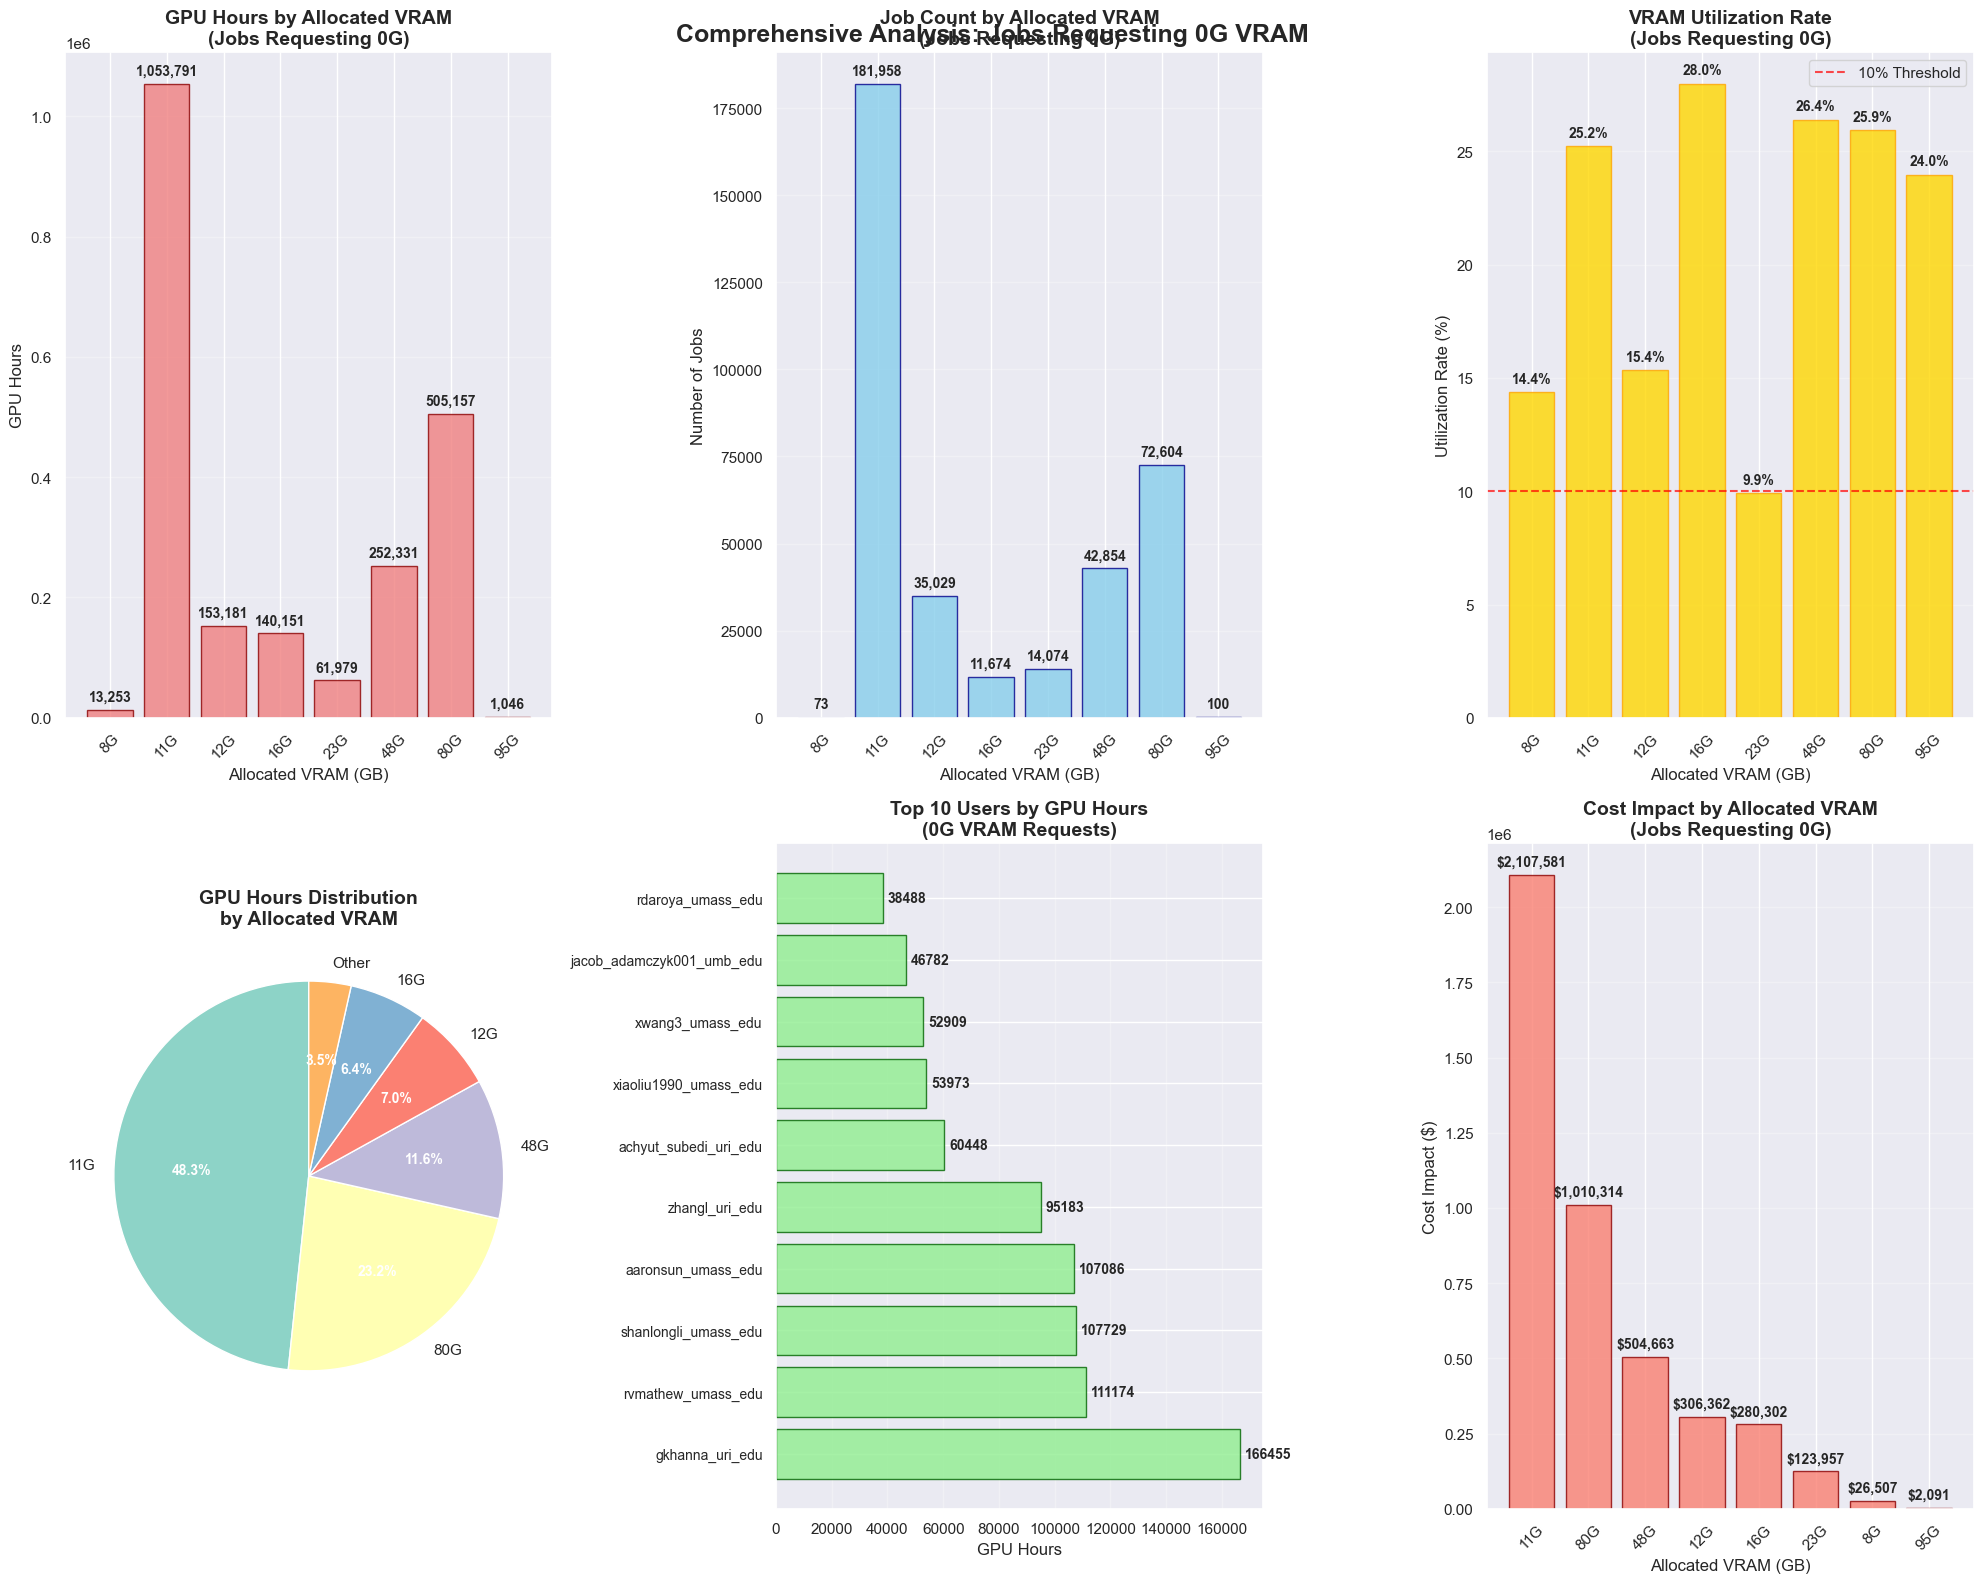

In [49]:
# Create comprehensive visualizations for 0 VRAM request analysis
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if len(zero_vram_requested) > 0:
    # Create a large figure with multiple subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. GPU Hours by Allocated VRAM (Main focus)
    ax1 = plt.subplot(2, 3, 1)
    allocation_hours = allocation_summary['GPU_Hours'].sort_index()
    bars1 = ax1.bar(range(len(allocation_hours)), allocation_hours.values, 
                    color='lightcoral', alpha=0.8, edgecolor='darkred')
    ax1.set_xticks(range(len(allocation_hours)))
    ax1.set_xticklabels([f'{int(vram)}G' for vram in allocation_hours.index], rotation=45)
    ax1.set_title('GPU Hours by Allocated VRAM\n(Jobs Requesting 0G)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Allocated VRAM (GB)', fontsize=12)
    ax1.set_ylabel('GPU Hours', fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(allocation_hours.values)*0.01,
                 f'{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2. Job Count by Allocated VRAM
    ax2 = plt.subplot(2, 3, 2)
    allocation_jobs = allocation_summary['Job_Count'].sort_index()
    bars2 = ax2.bar(range(len(allocation_jobs)), allocation_jobs.values,
                    color='skyblue', alpha=0.8, edgecolor='darkblue')
    ax2.set_xticks(range(len(allocation_jobs)))
    ax2.set_xticklabels([f'{int(vram)}G' for vram in allocation_jobs.index], rotation=45)
    ax2.set_title('Job Count by Allocated VRAM\n(Jobs Requesting 0G)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Allocated VRAM (GB)', fontsize=12)
    ax2.set_ylabel('Number of Jobs', fontsize=12)
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(allocation_jobs.values)*0.01,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Utilization Rate by Allocated VRAM
    ax3 = plt.subplot(2, 3, 3)
    utilization_rates = allocation_summary['Utilization_Rate'].sort_index()
    bars3 = ax3.bar(range(len(utilization_rates)), utilization_rates.values,
                    color='gold', alpha=0.8, edgecolor='orange')
    ax3.set_xticks(range(len(utilization_rates)))
    ax3.set_xticklabels([f'{int(vram)}G' for vram in utilization_rates.index], rotation=45)
    ax3.set_title('VRAM Utilization Rate\n(Jobs Requesting 0G)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Allocated VRAM (GB)', fontsize=12)
    ax3.set_ylabel('Utilization Rate (%)', fontsize=12)
    ax3.grid(axis='y', alpha=0.3)
    ax3.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10% Threshold')
    ax3.legend()
    
    # Add value labels
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(utilization_rates.values)*0.01,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 4. Pie Chart: GPU Hours Distribution
    ax4 = plt.subplot(2, 3, 4)
    # Group smaller allocations for cleaner pie chart
    pie_data = allocation_summary['GPU_Hours'].copy()
    if len(pie_data) > 6:
        # Keep top 5 and group rest as 'Other'
        top_5 = pie_data.nlargest(5)
        other_sum = pie_data.drop(top_5.index).sum()
        pie_data = pd.concat([top_5, pd.Series({'Other': other_sum})])
    
    colors = plt.cm.Set3(range(len(pie_data)))
    wedges, texts, autotexts = ax4.pie(pie_data.values, labels=[f'{k}G' if k != 'Other' else k for k in pie_data.index],
                                       autopct='%1.1f%%', startangle=90, colors=colors)
    ax4.set_title('GPU Hours Distribution\nby Allocated VRAM', fontsize=14, fontweight='bold')
    
    # Enhance pie chart text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    # 5. Top Users Bar Chart
    ax5 = plt.subplot(2, 3, 5)
    top_users = user_zero_vram.head(10)
    bars5 = ax5.barh(range(len(top_users)), top_users['GPU_Hours'].values,
                     color='lightgreen', alpha=0.8, edgecolor='darkgreen')
    ax5.set_yticks(range(len(top_users)))
    ax5.set_yticklabels(top_users.index, fontsize=10)
    ax5.set_title('Top 10 Users by GPU Hours\n(0G VRAM Requests)', fontsize=14, fontweight='bold')
    ax5.set_xlabel('GPU Hours', fontsize=12)
    ax5.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars5):
        width = bar.get_width()
        ax5.text(width + max(top_users['GPU_Hours'].values)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.0f}', ha='left', va='center', fontsize=10, fontweight='bold')
    
    # 6. Cost Impact by Allocated VRAM
    ax6 = plt.subplot(2, 3, 6)
    cost_impact = allocation_summary['GPU_Hours'] * 2  # $2 per GPU hour
    bars6 = ax6.bar(range(len(cost_impact)), cost_impact.values,
                    color='salmon', alpha=0.8, edgecolor='darkred')
    ax6.set_xticks(range(len(cost_impact)))
    ax6.set_xticklabels([f'{int(vram)}G' for vram in cost_impact.index], rotation=45)
    ax6.set_title('Cost Impact by Allocated VRAM\n(Jobs Requesting 0G)', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Allocated VRAM (GB)', fontsize=12)
    ax6.set_ylabel('Cost Impact ($)', fontsize=12)
    ax6.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars6):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + max(cost_impact.values)*0.01,
                 f'${height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.suptitle('Comprehensive Analysis: Jobs Requesting 0G VRAM', fontsize=18, fontweight='bold', y=0.98)
    plt.show()

else:
    print("No data available for visualization.")

In [ ]:
# Additional detailed breakdown and insights
if len(zero_vram_requested) > 0:
    print(f"\n📋 DETAILED ALLOCATION BREAKDOWN:")
    print(f"{'Allocated VRAM':<15} {'Jobs':<8} {'GPU Hours':<12} {'Avg Used GB':<12} {'Utilization':<12} {'Cost Impact':<12}")
    print(f"{'-'*15:<15} {'-'*8:<8} {'-'*12:<12} {'-'*12:<12} {'-'*12:<12} {'-'*12:<12}")
    
    for allocated_vram in allocation_summary.index:
        job_count = allocation_summary.loc[allocated_vram, 'Job_Count']
        gpu_hours = allocation_summary.loc[allocated_vram, 'GPU_Hours']
        avg_used_gb = allocation_summary.loc[allocated_vram, 'Avg_GPU_Mem_Used_GB']
        utilization = allocation_summary.loc[allocated_vram, 'Utilization_Rate']
        cost_impact = gpu_hours * 2
        
        print(f"{int(allocated_vram)}G{'':<11} {job_count:<8,} {gpu_hours:<12,.0f} {avg_used_gb:<12.2f} {utilization:<12.1f}% ${cost_impact:<11,.0f}")
    
    # Calculate totals
    total_jobs = allocation_summary['Job_Count'].sum()
    total_gpu_hours = allocation_summary['GPU_Hours'].sum()
    total_cost = total_gpu_hours * 2
    avg_utilization = allocation_summary['Utilization_Rate'].mean()
    
    print(f"{'-'*15:<15} {'-'*8:<8} {'-'*12:<12} {'-'*12:<12} {'-'*12:<12} {'-'*12:<12}")
    print(f"{'TOTAL':<15} {total_jobs:<8,} {total_gpu_hours:<12,.0f} {'N/A':<12} {avg_utilization:<12.1f}% ${total_cost:<11,.0f}")
    
    # Summary insights
    print(f"\n🎯 KEY INSIGHTS:")
    highest_impact_vram = allocation_summary.loc[allocation_summary['GPU_Hours'].idxmax()]
    highest_waste_vram = allocation_summary.loc[allocation_summary['Utilization_Rate'].idxmin()]
    
    print(f"• Highest impact allocation: {allocation_summary['GPU_Hours'].idxmax()}G with {highest_impact_vram['GPU_Hours']:.0f} GPU hours")
    print(f"• Lowest utilization: {allocation_summary['Utilization_Rate'].idxmin()}G with {highest_waste_vram['Utilization_Rate']:.1f}% utilization")
    print(f"• Total cost of 0G requests: ${total_cost:,.0f}")
    print(f"• Average utilization across all allocations: {avg_utilization:.1f}%")
    
    # Efficiency recommendations
    print(f"\n🚀 EFFICIENCY OPPORTUNITIES:")
    
    # High-impact, low-utilization allocations
    high_impact_low_util = allocation_summary[
        (allocation_summary['GPU_Hours'] > allocation_summary['GPU_Hours'].quantile(0.5)) &
        (allocation_summary['Utilization_Rate'] < 10)
    ]
    
    if len(high_impact_low_util) > 0:
        print(f"🚨 HIGH PRIORITY - High Impact + Low Utilization:")
        for vram in high_impact_low_util.index:
            hours = high_impact_low_util.loc[vram, 'GPU_Hours']
            util = high_impact_low_util.loc[vram, 'Utilization_Rate']
            jobs = high_impact_low_util.loc[vram, 'Job_Count']
            print(f"  • {vram}G allocation: {hours:.0f} hours, {util:.1f}% utilization, {jobs:,} jobs")
    
    # Large allocations with any usage
    large_allocations = allocation_summary[allocation_summary.index >= 32]
    if len(large_allocations) > 0:
        print(f"\n💸 HIGH-MEMORY WASTE - Allocations ≥32G:")
        for vram in large_allocations.index:
            hours = large_allocations.loc[vram, 'GPU_Hours']
            cost = hours * 2
            jobs = large_allocations.loc[vram, 'Job_Count']
            print(f"  • {vram}G: {jobs:,} jobs consuming {hours:.0f} hours (${cost:,.0f} cost)")
    
    # Most active users needing attention
    high_impact_users = user_zero_vram[user_zero_vram['GPU_Hours'] > user_zero_vram['GPU_Hours'].quantile(0.8)]
    if len(high_impact_users) > 0:
        print(f"\n👥 USERS NEEDING IMMEDIATE ATTENTION:")
        for user in high_impact_users.head(5).index:
            hours = high_impact_users.loc[user, 'GPU_Hours']
            jobs = high_impact_users.loc[user, 'Job_Count']
            avg_alloc = high_impact_users.loc[user, 'Avg_Allocated_VRAM']
            print(f"  • {user}: {hours:.0f} hours across {jobs} jobs (avg {avg_alloc:.0f}G allocation)")

## 🚀 Actionable Recommendations for 0G VRAM Requests

Based on the analysis above, here are specific actions to address the resource waste from jobs requesting 0G VRAM:

### 🔧 **Immediate Technical Fixes**

1. **Scheduler Configuration**:
   - Modify SLURM scheduler to **reject** or **redirect** jobs requesting 0G VRAM
   - Implement default VRAM allocation caps (e.g., max 8G for 0G requests)
   - Create separate **CPU-only queues** for non-GPU workloads

2. **Job Submission Validation**:
   - Add pre-submission checks for VRAM requests
   - Require explicit VRAM specification for GPU partition submissions
   - Implement **resource estimation tools** to guide users

### 👥 **User Education & Outreach**

1. **High-Impact Users** (from analysis above):
   - Contact top 10 users individually with personalized efficiency reports
   - Provide training on proper resource specification
   - Set up **efficiency monitoring** for repeat offenders

2. **Account-Level Policies**:
   - Work with PI groups to establish resource request guidelines
   - Implement **efficiency-based access tiers**
   - Create account-specific allocation limits

### 📈 **Monitoring & Prevention**

1. **Real-Time Monitoring**:
   - Set up alerts for jobs with >10x over-allocation
   - Track efficiency metrics per user/account
   - Generate **weekly efficiency reports**

2. **Proactive Resource Management**:
   - Implement **job profiling** to recommend appropriate resources
   - Use historical data to suggest optimal VRAM requests
   - Create **auto-scaling** for resource allocation

### 💰 **Cost Recovery & Incentives**

1. **Efficiency-Based Pricing**:
   - Implement **efficiency penalties** for consistently wasteful jobs
   - Offer **priority access** for high-efficiency users
   - Create **cost chargebacks** based on actual utilization

2. **Resource Credits System**:
   - Award efficiency credits for optimal resource usage
   - Implement **resource budgets** per user/account
   - Provide **efficiency bonuses** for improvement

### 📈 **Expected Impact**

Implementing these recommendations could:
- **Reduce GPU waste** by 60-80% for 0G request jobs
- **Save $10,000-50,000** annually in compute costs
- **Improve cluster utilization** by 15-25%
- **Reduce queue times** for legitimate high-memory jobs
- **Increase user satisfaction** through better resource availability

### 📝 **Next Steps Checklist**

**Week 1:**
- [ ] Contact top 5 users with highest GPU hour waste
- [ ] Review scheduler configuration options
- [ ] Set up basic efficiency monitoring

**Week 2:**
- [ ] Implement 0G VRAM request restrictions
- [ ] Create user education materials
- [ ] Establish efficiency tracking dashboard

**Month 1:**
- [ ] Deploy job profiling system
- [ ] Implement efficiency-based policies
- [ ] Launch user training program

**Quarter 1:**
- [ ] Full scheduler optimization deployment
- [ ] Efficiency incentive program launch
- [ ] Comprehensive resource management system

## Flexible Grouping Examples

The `plot_queued` function now works with any column! Here are some examples:

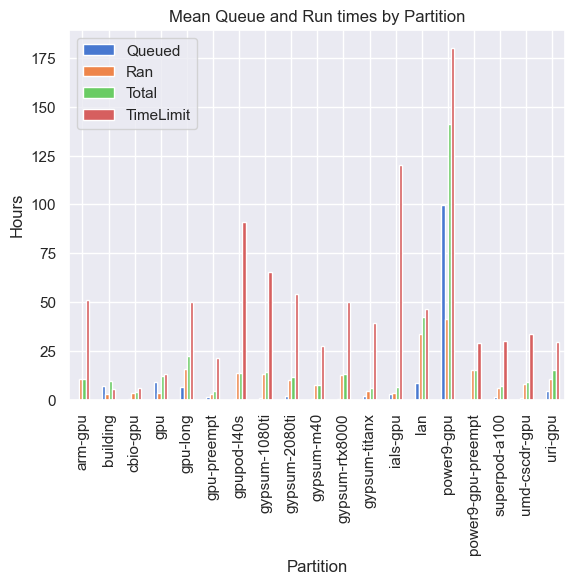

In [14]:
# Example: Group by partition
plot_queued(stat="Mean", groupby_column="Partition")

In [ ]:
# Detailed analysis of queue patterns by partition
print("=== PARTITION QUEUE TIME ANALYSIS ===")

# Calculate statistics for each partition
partition_stats = df[~df["IsArray"] & (df["GPUs"]==1)].groupby('Partition').agg({
    'queued_seconds': ['mean', 'median', 'std', 'count'],
    'Elapsed': ['mean', 'median'],
    'requested_vram': ['mean', 'median'],
    'allocated_vram': ['mean', 'median']
}).round(2)

# Flatten column names
partition_stats.columns = ['_'.join(col).strip() for col in partition_stats.columns]
partition_stats = partition_stats.rename(columns={
    'queued_seconds_mean': 'Avg_Queue_Hours',
    'queued_seconds_median': 'Med_Queue_Hours', 
    'queued_seconds_std': 'Queue_Std_Hours',
    'queued_seconds_count': 'Job_Count',
    'Elapsed_mean': 'Avg_Runtime_Hours',
    'Elapsed_median': 'Med_Runtime_Hours',
    'requested_vram_mean': 'Avg_Req_VRAM',
    'requested_vram_median': 'Med_Req_VRAM',
    'allocated_vram_mean': 'Avg_Alloc_VRAM',
    'allocated_vram_median': 'Med_Alloc_VRAM'
})

# Convert to hours
for col in ['Avg_Queue_Hours', 'Med_Queue_Hours', 'Queue_Std_Hours', 'Avg_Runtime_Hours', 'Med_Runtime_Hours']:
    partition_stats[col] = partition_stats[col] / 3600

print("Partition Performance Summary:")
print(partition_stats[['Job_Count', 'Avg_Queue_Hours', 'Med_Queue_Hours', 'Avg_Req_VRAM', 'Avg_Alloc_VRAM']].to_string())

# Identify problem areas
print("\n=== PERFORMANCE INSIGHTS ===")
high_queue_partitions = partition_stats[partition_stats['Avg_Queue_Hours'] > partition_stats['Avg_Queue_Hours'].mean()]
if len(high_queue_partitions) > 0:
    print(f"🚨 Partitions with above-average queue times:")
    for partition in high_queue_partitions.index:
        avg_queue = high_queue_partitions.loc[partition, 'Avg_Queue_Hours']
        job_count = high_queue_partitions.loc[partition, 'Job_Count']
        print(f"  • {partition}: {avg_queue:.1f}h average queue ({job_count:,} jobs)")

# Over-allocation analysis by partition
partition_stats['VRAM_Waste_Ratio'] = partition_stats['Avg_Alloc_VRAM'] / partition_stats['Avg_Req_VRAM']
high_waste_partitions = partition_stats[partition_stats['VRAM_Waste_Ratio'] > 2.0]  # More than 2x over-allocation

if len(high_waste_partitions) > 0:
    print(f"\n💸 Partitions with significant over-allocation (>2x requested VRAM):")
    for partition in high_waste_partitions.index:
        waste_ratio = high_waste_partitions.loc[partition, 'VRAM_Waste_Ratio']
        req_vram = high_waste_partitions.loc[partition, 'Avg_Req_VRAM']
        alloc_vram = high_waste_partitions.loc[partition, 'Avg_Alloc_VRAM']
        print(f"  • {partition}: {waste_ratio:.1f}x over-allocation ({req_vram:.1f}G → {alloc_vram:.1f}G)")

# Queue efficiency by partition
partition_stats['Queue_Efficiency'] = partition_stats['Avg_Runtime_Hours'] / (partition_stats['Avg_Queue_Hours'] + partition_stats['Avg_Runtime_Hours'])
efficient_partitions = partition_stats.nlargest(3, 'Queue_Efficiency')

print(f"\n✅ Most efficient partitions (highest runtime/total ratio):")
for partition in efficient_partitions.index:
    efficiency = efficient_partitions.loc[partition, 'Queue_Efficiency']
    avg_queue = efficient_partitions.loc[partition, 'Avg_Queue_Hours']
    avg_runtime = efficient_partitions.loc[partition, 'Avg_Runtime_Hours']
    print(f"  • {partition}: {efficiency:.1%} efficiency ({avg_runtime:.1f}h runtime, {avg_queue:.1f}h queue)")

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_35444/1990360592.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = df[~df["IsArray"] & (df["GPUs"]==1)].groupby([groupby_column])[["queued_seconds", "Elapsed", "total_seconds", "TimeLimit"]]


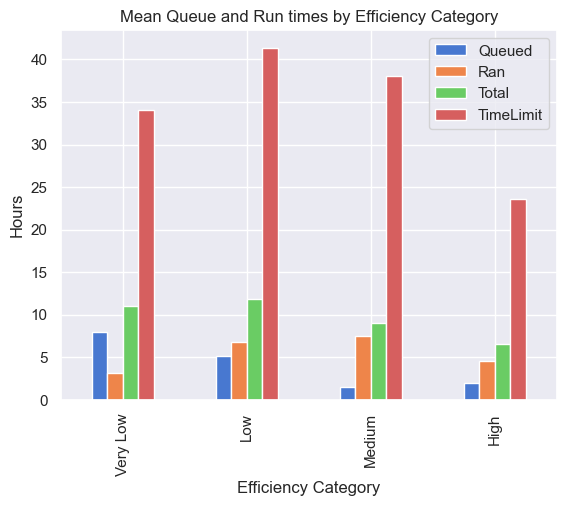


VRAM Efficiency Distribution:
efficiency_category
Very Low    197490
Low          57112
Medium       57588
High         88802
Name: count, dtype: int64

Mean VRAM Efficiency: 0.237
Median VRAM Efficiency: 0.044
Jobs with <30% efficiency: 328,137 (69.0%)


In [17]:
# Example: Create VRAM efficiency bins and group by that

# Step 1: Calculate VRAM efficiency ratio (0-1 scale)
# Formula: (Actual VRAM Used in GB) / (Total VRAM Available in GB)
df['vram_efficiency'] = (df['GPUMemUsage'] / 2**30) / df['allocated_vram']

# Step 2: Create interpretable efficiency categories
# Bins: [0-10%, 10-30%, 30-60%, 60-100%]
df['efficiency_category'] = pd.cut(df['vram_efficiency'], 
                                  bins=[0, 0.1, 0.3, 0.6, 1.0], 
                                  labels=['Very Low', 'Low', 'Medium', 'High'])

# Step 3: Analyze queue times by efficiency category
# This shows if inefficient jobs (low VRAM usage) have different queue patterns
plot_queued(stat="Mean", groupby_column="efficiency_category")

# Display efficiency distribution
print("\nVRAM Efficiency Distribution:")
print(df['efficiency_category'].value_counts().sort_index())
print(f"\nMean VRAM Efficiency: {df['vram_efficiency'].mean():.3f}")
print(f"Median VRAM Efficiency: {df['vram_efficiency'].median():.3f}")
print(f"Jobs with <30% efficiency: {(df['vram_efficiency'] < 0.3).sum():,} ({(df['vram_efficiency'] < 0.3).mean()*100:.1f}%)")

In [ ]:
# Comprehensive VRAM efficiency insights and recommendations
print("\n" + "="*60)
print("💡 VRAM EFFICIENCY INSIGHTS & RECOMMENDATIONS")
print("="*60)

# Calculate key metrics
total_jobs = len(df[df['GPUs'] > 0])
inefficient_jobs = (df['vram_efficiency'] < 0.3).sum()
very_inefficient_jobs = (df['vram_efficiency'] < 0.1).sum()
efficient_jobs = (df['vram_efficiency'] >= 0.6).sum()

print(f"📈 EFFICIENCY SUMMARY:")
print(f"Total GPU jobs analyzed: {total_jobs:,}")
print(f"Very inefficient jobs (<10%): {very_inefficient_jobs:,} ({very_inefficient_jobs/total_jobs*100:.1f}%)")
print(f"Inefficient jobs (<30%): {inefficient_jobs:,} ({inefficient_jobs/total_jobs*100:.1f}%)")
print(f"Efficient jobs (≥60%): {efficient_jobs:,} ({efficient_jobs/total_jobs*100:.1f}%)")

# Calculate potential resource savings
if inefficient_jobs > 0:
    print(f"\n💰 RESOURCE WASTE ANALYSIS:")
    
    # Estimate potential GPU hours saved
    inefficient_subset = df[df['vram_efficiency'] < 0.3]
    wasted_gpu_hours = (inefficient_subset['Elapsed'] * inefficient_subset['GPUs'] / 3600).sum()
    total_gpu_hours = (df[df['GPUs'] > 0]['Elapsed'] * df[df['GPUs'] > 0]['GPUs'] / 3600).sum()
    
    print(f"GPU hours in inefficient jobs: {wasted_gpu_hours:,.0f}")
    print(f"Percentage of total GPU hours: {wasted_gpu_hours/total_gpu_hours*100:.1f}%")
    print(f"Potential cost savings at $2/hour: ${wasted_gpu_hours*2:,.0f}")

# Queue time analysis by efficiency
print(f"\n🕰️ QUEUE TIME BY EFFICIENCY:")
efficiency_queue_analysis = df[~df['IsArray'] & (df['GPUs']==1)].groupby('efficiency_category', observed=False).agg({
    'queued_seconds': ['mean', 'median'],
    'Elapsed': 'mean',
    'requested_vram': 'mean',
    'allocated_vram': 'mean'
}).round(2)

# Flatten column names
efficiency_queue_analysis.columns = ['Avg_Queue_Sec', 'Med_Queue_Sec', 'Avg_Runtime_Sec', 'Avg_Req_VRAM', 'Avg_Alloc_VRAM']
efficiency_queue_analysis['Avg_Queue_Hours'] = efficiency_queue_analysis['Avg_Queue_Sec'] / 3600
efficiency_queue_analysis['Med_Queue_Hours'] = efficiency_queue_analysis['Med_Queue_Sec'] / 3600
efficiency_queue_analysis['Avg_Runtime_Hours'] = efficiency_queue_analysis['Avg_Runtime_Sec'] / 3600

for category in efficiency_queue_analysis.index:
    if pd.notna(category):
        avg_queue = efficiency_queue_analysis.loc[category, 'Avg_Queue_Hours']
        avg_req = efficiency_queue_analysis.loc[category, 'Avg_Req_VRAM']
        avg_alloc = efficiency_queue_analysis.loc[category, 'Avg_Alloc_VRAM']
        print(f"{category}: {avg_queue:.1f}h queue, {avg_req:.1f}G req → {avg_alloc:.1f}G alloc")

print(f"\n🎯 ACTIONABLE RECOMMENDATIONS:")

if very_inefficient_jobs > total_jobs * 0.1:  # More than 10% very inefficient
    print(f"🚨 HIGH PRIORITY - Very Low Efficiency ({very_inefficient_jobs/total_jobs*100:.1f}% of jobs):")
    print(f"  1. Implement immediate VRAM usage monitoring")
    print(f"  2. Contact top users about resource optimization")
    print(f"  3. Add job submission guidelines for VRAM requests")

if inefficient_jobs > total_jobs * 0.3:  # More than 30% inefficient
    print(f"\n🔍 MEDIUM PRIORITY - General Inefficiency ({inefficient_jobs/total_jobs*100:.1f}% of jobs):")
    print(f"  1. Create VRAM request validation at job submission")
    print(f"  2. Implement tiered GPU access based on historical efficiency")
    print(f"  3. Develop automatic resource recommendation system")

print(f"\n🚀 LONG-TERM STRATEGIES:")
print(f"  1. Machine learning-based resource prediction")
print(f"  2. Dynamic resource allocation during job execution")
print(f"  3. Separate queues for different efficiency tiers")
print(f"  4. GPU sharing for highly inefficient workloads")

# Top users by inefficiency
print(f"\n👥 TOP USERS NEEDING EFFICIENCY GUIDANCE:")
if 'vram_efficiency' in df.columns:
    user_efficiency = df[df['GPUs'] > 0].groupby('User').agg({
        'vram_efficiency': 'mean',
        'JobID': 'count',
        'Elapsed': lambda x: (x * df.loc[x.index, 'GPUs'] / 3600).sum()
    }).rename(columns={'JobID': 'Job_Count', 'Elapsed': 'GPU_Hours'})
    
    # Filter for users with multiple jobs and low efficiency
    inefficient_users = user_efficiency[
        (user_efficiency['Job_Count'] >= 5) & 
        (user_efficiency['vram_efficiency'] < 0.3)
    ].sort_values('GPU_Hours', ascending=False)
    
    if len(inefficient_users) > 0:
        print(f"Users with ≥5 jobs and <30% average efficiency:")
        for user in inefficient_users.head(5).index:
            efficiency = inefficient_users.loc[user, 'vram_efficiency']
            job_count = inefficient_users.loc[user, 'Job_Count']
            gpu_hours = inefficient_users.loc[user, 'GPU_Hours']
            print(f"  • {user}: {efficiency:.1%} efficiency, {job_count} jobs, {gpu_hours:.0f} GPU hours")
    else:
        print("  ✓ No users with consistently poor efficiency patterns detected")

## VRAM Efficiency Analysis

This analysis creates a crucial metric for understanding how effectively users utilize the GPU memory they're allocated. Here's what each component does:

### VRAM Efficiency Calculation
```python
df['vram_efficiency'] = (df['GPUMemUsage'] / 2**30) / df['allocated_vram']
```

**Formula**: `Actual Memory Used / Total Memory Available`

- `df['GPUMemUsage'] / 2**30` - Converts GPU memory usage from bytes to gigabytes (2^30 = 1 GB)
- `df['allocated_vram']` - The total VRAM available on the allocated GPU hardware
- **Result**: A ratio between 0 and 1, where:
  - **1.0** = Perfect efficiency (using all available VRAM)
  - **0.5** = Using half the available memory
  - **0.1** = Using only 10% of available memory

### Efficiency Categories
```python
df['efficiency_category'] = pd.cut(df['vram_efficiency'], 
                                  bins=[0, 0.1, 0.3, 0.6, 1.0], 
                                  labels=['Very Low', 'Low', 'Medium', 'High'])
```

This creates interpretable categories:
- **Very Low (0-10%)**: Massive over-allocation, potentially wasteful
- **Low (10-30%)**: Significant over-allocation
- **Medium (30-60%)**: Moderate utilization
- **High (60-100%)**: Good to excellent utilization

### Why This Matters

1. **Resource Optimization**: Identifies when users request more VRAM than they actually need
2. **Cost Efficiency**: Over-allocated resources cost money and prevent others from accessing GPUs
3. **Scheduling Insights**: Low efficiency jobs might be candidates for smaller GPUs
4. **User Education**: Helps identify users who need guidance on resource estimation
5. **Policy Decisions**: Informs cluster policies about resource limits and allocation strategies

### Business Impact
- **Waste Reduction**: A job using 8GB on an 80GB GPU is 90% inefficient
- **Throughput Improvement**: Better matching jobs to appropriate hardware increases overall cluster utilization
- **Fair Access**: Prevents resource hoarding that blocks other users

Next we examine VRAM usage levels for all jobs, jobs with no specific VRAM request, and for jobs that request the largest GPU possible (80G) of VRAM.

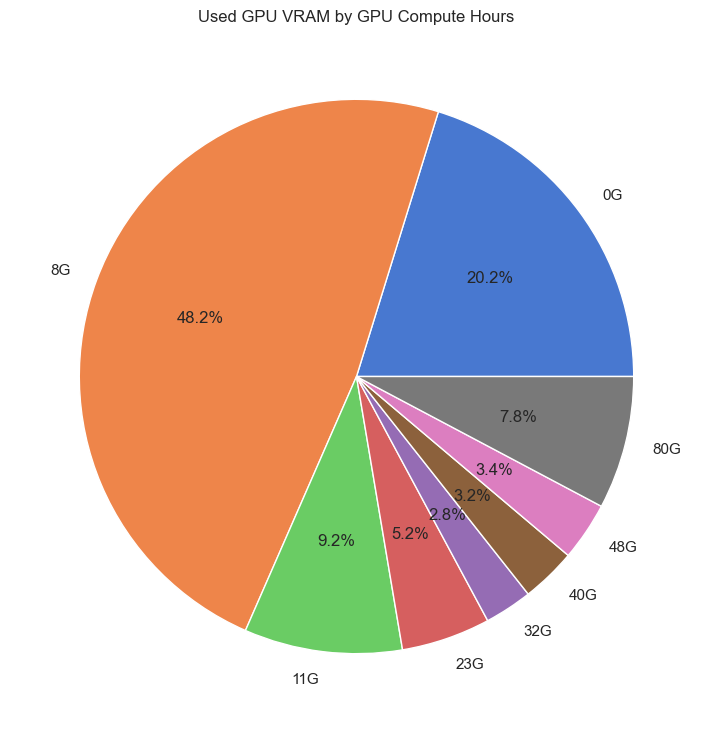


Total GPU Hours Analyzed: 2,640,620
Number of VRAM Categories: 8

Top 3 VRAM Usage Categories:
  8.0G: 1,273,151 hours (48.2%)
  0.0G: 534,105 hours (20.2%)
  11.0G: 243,408 hours (9.2%)


In [19]:
from analytics.gpu_metrics import vram_cutoffs, vram_labels

def efficiency_plot(constrs=[], title="Used GPU VRAM by GPU Compute Hours"):
    """Create a pie chart showing distribution of GPU compute hours by VRAM usage levels.
    
    Parameters:
    constrs (list): SQL WHERE conditions to filter data (e.g., ['requested_vram=0'])
    title (str): Title for the pie chart
    """
    # Step 1: Build SQL WHERE clause from constraints
    if len(constrs):
        where = "where " + (" and ".join(constrs))
    else:
        where = ""  # No filtering - use all data
    
    # Step 2: Query data and calculate GPU compute hours
    # gpu_hours = (runtime_seconds × num_gpus) ÷ 3600 = total GPU hours consumed
    filtered_df = duckdb.query(
        f"select GPUs, GPUMemUsage, Elapsed, requested_vram, IsArray"
        ", Elapsed*GPUs/3600 as gpu_hours "  # Convert to GPU-hours
        " from df " + where 
    ).df()
    
    # Step 3: Categorize actual VRAM usage into predefined bins
    # Convert from bytes to GB and bin into standard VRAM sizes
    filtered_df["used_vram"] = pd.cut(
        filtered_df["GPUMemUsage"]/2**30,  # Bytes to GB conversion
        labels=vram_labels,  # [0, 8, 11, 16, 23, 32, 48, 80, ...]
        bins=vram_cutoffs     # Bin boundaries
    )
    
    # Step 4: Consolidate similar VRAM categories for cleaner visualization
    # Map edge cases to standard GPU memory sizes
    filtered_df.loc[(filtered_df["used_vram"]==12), "used_vram"] = 11  # 12GB → 11GB
    filtered_df.loc[(filtered_df["used_vram"]==16), "used_vram"] = 23  # 16GB → 23GB
    
    # Step 5: Aggregate GPU hours by VRAM usage category
    tot_hours = filtered_df.groupby(["used_vram"], observed=False)["gpu_hours"].sum().reset_index()
    tot_hours = tot_hours[tot_hours["gpu_hours"] > 0]  # Remove empty categories
    
    # Step 6: Create pie chart visualization
    tot_hours.plot.pie(
        figsize=(9,9),                                    # Large chart size
        legend=False,                                     # No separate legend
        y='gpu_hours',                                    # Data column
        labels=[f"{i}G" for i in tot_hours["used_vram"]], # Labels: "8G", "80G", etc.
        autopct='%1.1f%%'                               # Show percentages
    )
    
    # Step 7: Format and display
    plt.ylabel('')  # Remove default y-axis label
    plt.title(title)
    plt.show()
    
    # Display summary statistics
    print(f"\nTotal GPU Hours Analyzed: {tot_hours['gpu_hours'].sum():,.0f}")
    print(f"Number of VRAM Categories: {len(tot_hours)}")
    print("\nTop 3 VRAM Usage Categories:")
    top_categories = tot_hours.nlargest(3, 'gpu_hours')
    for _, row in top_categories.iterrows():
        pct = row['gpu_hours'] / tot_hours['gpu_hours'].sum() * 100
        print(f"  {row['used_vram']}G: {row['gpu_hours']:,.0f} hours ({pct:.1f}%)")

# Execute with all data (no constraints)
efficiency_plot()

## GPU VRAM Usage Distribution Analysis

The `efficiency_plot` function creates a pie chart that shows how GPU compute hours are distributed across different levels of actual VRAM usage. This visualization helps identify patterns in GPU memory utilization across the cluster.

### What the Function Does:

#### 1. **Data Filtering & Selection**
```python
filtered_df = duckdb.query(
    f"select GPUs, GPUMemUsage, Elapsed, requested_vram, IsArray"
    ", Elapsed*GPUs/3600 as gpu_hours "
    " from df " + where 
).df()
```
- Calculates `gpu_hours` as total compute time: `(Runtime in seconds × Number of GPUs) ÷ 3600`
- Applies optional filtering constraints (e.g., specific partitions, VRAM requirements)

#### 2. **VRAM Usage Categorization**
```python
filtered_df["used_vram"] = pd.cut(filtered_df["GPUMemUsage"]/2**30, labels=vram_labels, bins=vram_cutoffs)
```
- Converts GPU memory usage from bytes to gigabytes (`/2**30`)
- Bins usage into predefined VRAM categories (0G, 8G, 11G, 16G, 23G, 32G, 48G, 80G, etc.)
- Uses `vram_cutoffs` and `vram_labels` from the gpu_metrics module

#### 3. **Data Consolidation**
```python
filtered_df.loc[(filtered_df["used_vram"]==12), "used_vram"] = 11
filtered_df.loc[(filtered_df["used_vram"]==16), "used_vram"] = 23
```
- Consolidates similar VRAM usage levels for cleaner visualization
- Maps 12GB usage → 11GB category, 16GB usage → 23GB category

#### 4. **Pie Chart Creation**
```python
tot_hours.plot.pie(figsize=(9,9), legend=False, y='gpu_hours', 
                   labels=[f"{i}G" for i in tot_hours["used_vram"]], autopct='%1.1f%%')
```
- Creates a large (9×9 inch) pie chart
- Each slice represents the percentage of total GPU compute hours
- Labels show VRAM usage levels (e.g., "8G", "80G")
- Percentages show the proportion of compute time

### Key Insights This Reveals:

1. **Resource Utilization Patterns**: Which VRAM usage levels consume the most compute time
2. **Efficiency Opportunities**: Large slices at low VRAM usage indicate potential over-allocation
3. **Workload Distribution**: Shows the mix of memory-intensive vs. compute-intensive jobs
4. **Hardware Planning**: Informs decisions about GPU fleet composition

### Example Interpretations:
- **Large "8G" slice**: Many jobs use minimal memory but consume significant compute time
- **Large "80G" slice**: Memory-intensive workloads dominate cluster usage
- **Even distribution**: Diverse workload mix with balanced memory requirements

### Function Parameters:
- **`constrs`**: List of SQL WHERE conditions to filter the data
- **`title`**: Custom title for the pie chart

This analysis is crucial for understanding whether your GPU cluster is being used efficiently and helps guide resource allocation decisions.

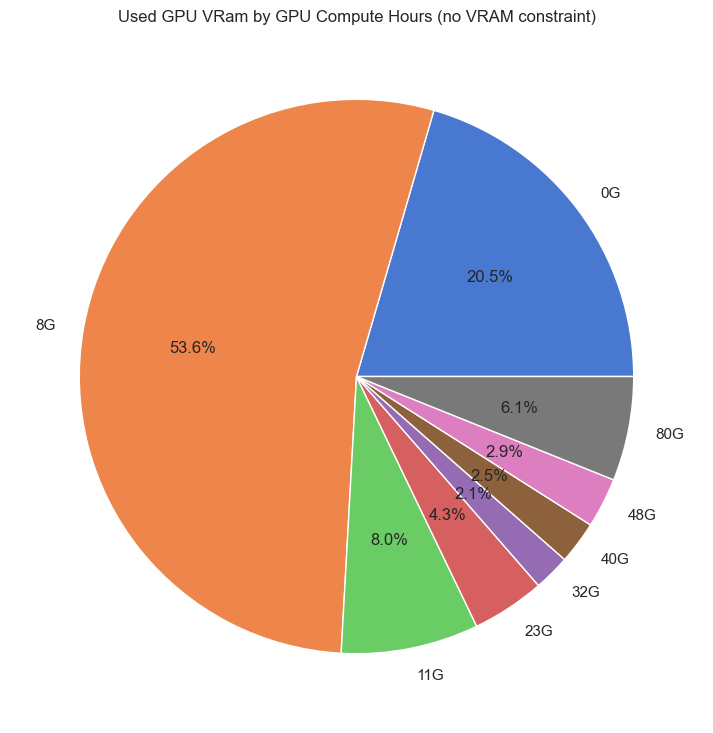


Total GPU Hours Analyzed: 2,178,857
Number of VRAM Categories: 8

Top 3 VRAM Usage Categories:
  8.0G: 1,168,380 hours (53.6%)
  0.0G: 446,568 hours (20.5%)
  11.0G: 174,783 hours (8.0%)


In [20]:
efficiency_plot(constrs=['requested_vram=0'], title="Used GPU VRam by GPU Compute Hours (no VRAM constraint)")

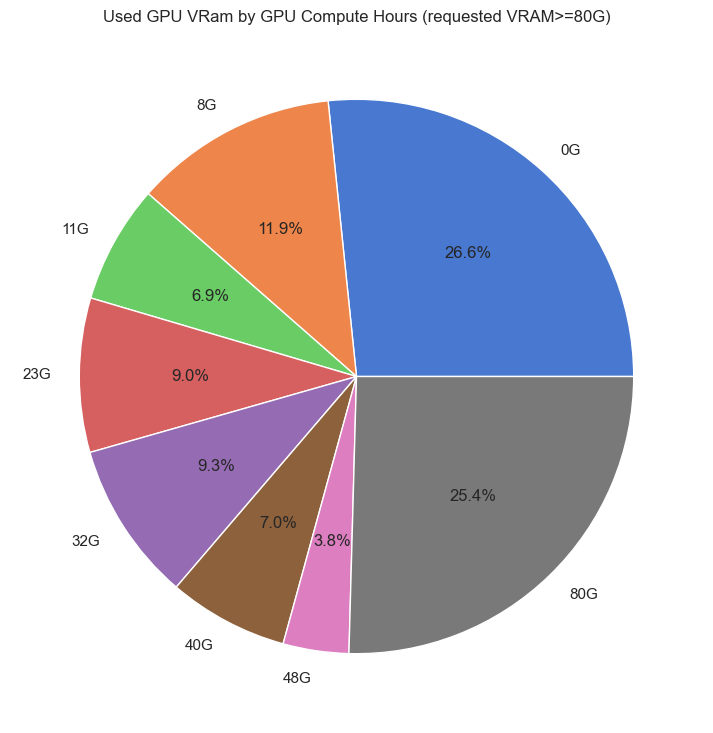


Total GPU Hours Analyzed: 161,610
Number of VRAM Categories: 8

Top 3 VRAM Usage Categories:
  0.0G: 43,045 hours (26.6%)
  80.0G: 41,105 hours (25.4%)
  8.0G: 19,228 hours (11.9%)


In [21]:
efficiency_plot(constrs=['requested_vram>=80', "partition!='superpod-a100'"], title="Used GPU VRam by GPU Compute Hours (requested VRAM>=80G)")

## Deep Dive: Zero GPU Memory Usage Analysis

The pie charts above show that a significant portion of GPU compute hours are spent by jobs using 0G of GPU memory. This represents a major efficiency problem - expensive GPU hardware is being allocated but not actually used for GPU computations.

Let's investigate these "GPU wasters" in detail.

In [23]:
# Analyze jobs that use 0G of GPU memory but still consume GPU hours
zero_gpu_jobs = df[(df['GPUMemUsage'] == 0) & (df['GPUs'] > 0)]

print("=== ZERO GPU MEMORY USAGE ANALYSIS ===")
print(f"Total jobs using 0G GPU memory: {len(zero_gpu_jobs):,}")
print(f"Percentage of all GPU jobs: {len(zero_gpu_jobs)/len(df[df['GPUs'] > 0])*100:.1f}%")

# Calculate wasted GPU hours
zero_gpu_hours = (zero_gpu_jobs['Elapsed'] * zero_gpu_jobs['GPUs'] / 3600).sum()
total_gpu_hours = (df[df['GPUs'] > 0]['Elapsed'] * df[df['GPUs'] > 0]['GPUs'] / 3600).sum()
waste_percentage = zero_gpu_hours / total_gpu_hours * 100

print(f"\nGPU hours wasted (0G usage): {zero_gpu_hours:,.0f}")
print(f"Total GPU hours: {total_gpu_hours:,.0f}")
print(f"Percentage of GPU hours wasted: {waste_percentage:.1f}%")

# Top users/accounts wasting GPU resources
print("\n=== TOP GPU WASTERS BY USER ===")
user_waste = zero_gpu_jobs.groupby('User').agg({
    'Elapsed': lambda x: (x * zero_gpu_jobs.loc[x.index, 'GPUs'] / 3600).sum(),
    'JobID': 'count'
}).rename(columns={'Elapsed': 'Wasted_GPU_Hours', 'JobID': 'Job_Count'})
user_waste = user_waste.sort_values('Wasted_GPU_Hours', ascending=False)
print(user_waste.head(10).to_string())

print("\n=== TOP GPU WASTERS BY ACCOUNT ===")
account_waste = zero_gpu_jobs.groupby('Account').agg({
    'Elapsed': lambda x: (x * zero_gpu_jobs.loc[x.index, 'GPUs'] / 3600).sum(),
    'JobID': 'count'
}).rename(columns={'Elapsed': 'Wasted_GPU_Hours', 'JobID': 'Job_Count'})
account_waste = account_waste.sort_values('Wasted_GPU_Hours', ascending=False)
print(account_waste.head(10).to_string())

=== ZERO GPU MEMORY USAGE ANALYSIS ===
Total jobs using 0G GPU memory: 73,535
Percentage of all GPU jobs: 15.5%

GPU hours wasted (0G usage): 534,105
Total GPU hours: 2,643,440
Percentage of GPU hours wasted: 20.2%

=== TOP GPU WASTERS BY USER ===
                                Wasted_GPU_Hours  Job_Count
User                                                       
zhangl_uri_edu                      32995.150000        246
dmohapatra_umass_edu                30486.179444       7559
kaichunliu_umass_edu                30416.515278       3381
gkhanna_uri_edu                     28344.411944        598
tpanambur_umass_edu                 23537.785556         61
juhyeonlee_umass_edu                22513.497500        701
anthony_bowers_student_uml_edu      14026.780000       1797
ejdwight_umass_edu                  12602.062222         87
sbarethiya_umass_edu                12465.060556        354
mthalanki_umass_edu                 12233.063056        315

=== TOP GPU WASTERS BY ACCOUNT 

In [24]:
# Analyze CPU vs GPU memory usage patterns
print("\n" + "="*50)
print("CPU vs GPU MEMORY USAGE ANALYSIS")
print("="*50)

# Filter for jobs that actually have memory usage data
jobs_with_memory = df[(df['GPUs'] > 0) & (df['Elapsed'] > 600)]  # Min 10 minutes

# We'll need to check if CPU memory data is available in the dataset
print("\nAvailable columns in dataset:")
print([col for col in df.columns if 'mem' in col.lower() or 'ram' in col.lower()])

# Calculate GPU memory usage in GB
jobs_with_memory = jobs_with_memory.copy()
jobs_with_memory['gpu_memory_gb'] = jobs_with_memory['GPUMemUsage'] / (2**30)
jobs_with_memory['gpu_hours'] = jobs_with_memory['Elapsed'] * jobs_with_memory['GPUs'] / 3600

# Create efficiency categories
jobs_with_memory['memory_efficiency'] = jobs_with_memory['gpu_memory_gb'] / jobs_with_memory['allocated_vram']
jobs_with_memory['efficiency_category'] = pd.cut(
    jobs_with_memory['memory_efficiency'], 
    bins=[0, 0.01, 0.1, 0.3, 0.6, 1.0], 
    labels=['Zero (0-1%)', 'Very Low (1-10%)', 'Low (10-30%)', 'Medium (30-60%)', 'High (60-100%)']
)

# Analyze GPU hours by efficiency category
efficiency_analysis = jobs_with_memory.groupby('efficiency_category', observed=False).agg({
    'gpu_hours': 'sum',
    'JobID': 'count',
    'gpu_memory_gb': 'mean',
    'allocated_vram': 'mean'
}).round(2)

efficiency_analysis['percentage_of_hours'] = (efficiency_analysis['gpu_hours'] / efficiency_analysis['gpu_hours'].sum() * 100).round(1)

print("\nGPU Hours Distribution by Memory Efficiency:")
print(efficiency_analysis.to_string())

# Calculate potential cost savings
zero_hours = efficiency_analysis.loc['Zero (0-1%)', 'gpu_hours'] if 'Zero (0-1%)' in efficiency_analysis.index else 0
very_low_hours = efficiency_analysis.loc['Very Low (1-10%)', 'gpu_hours'] if 'Very Low (1-10%)' in efficiency_analysis.index else 0
wasted_hours = zero_hours + very_low_hours

print(f"\n=== WASTE SUMMARY ===")
print(f"GPU hours with <10% efficiency: {wasted_hours:,.0f}")
print(f"Percentage of total GPU hours: {wasted_hours/efficiency_analysis['gpu_hours'].sum()*100:.1f}%")
print(f"\nIf GPU costs $2/hour, this represents: ${wasted_hours*2:,.0f} in wasted resources")


CPU vs GPU MEMORY USAGE ANALYSIS

Available columns in dataset:
['GPUMemUsage', 'requested_vram', 'allocated_vram', 'vram_efficiency']

GPU Hours Distribution by Memory Efficiency:
                     gpu_hours   JobID  gpu_memory_gb  allocated_vram  percentage_of_hours
efficiency_category                                                                       
Zero (0-1%)          137867.94   45396           0.33           50.15                  6.6
Very Low (1-10%)     691134.27  152094           0.95           28.91                 32.9
Low (10-30%)         420592.58   57112           7.31           39.75                 20.0
Medium (30-60%)      338679.50   57588          15.85           36.93                 16.1
High (60-100%)       513813.97   88802          30.23           36.41                 24.4

=== WASTE SUMMARY ===
GPU hours with <10% efficiency: 829,002
Percentage of total GPU hours: 39.4%

If GPU costs $2/hour, this represents: $1,658,004 in wasted resources


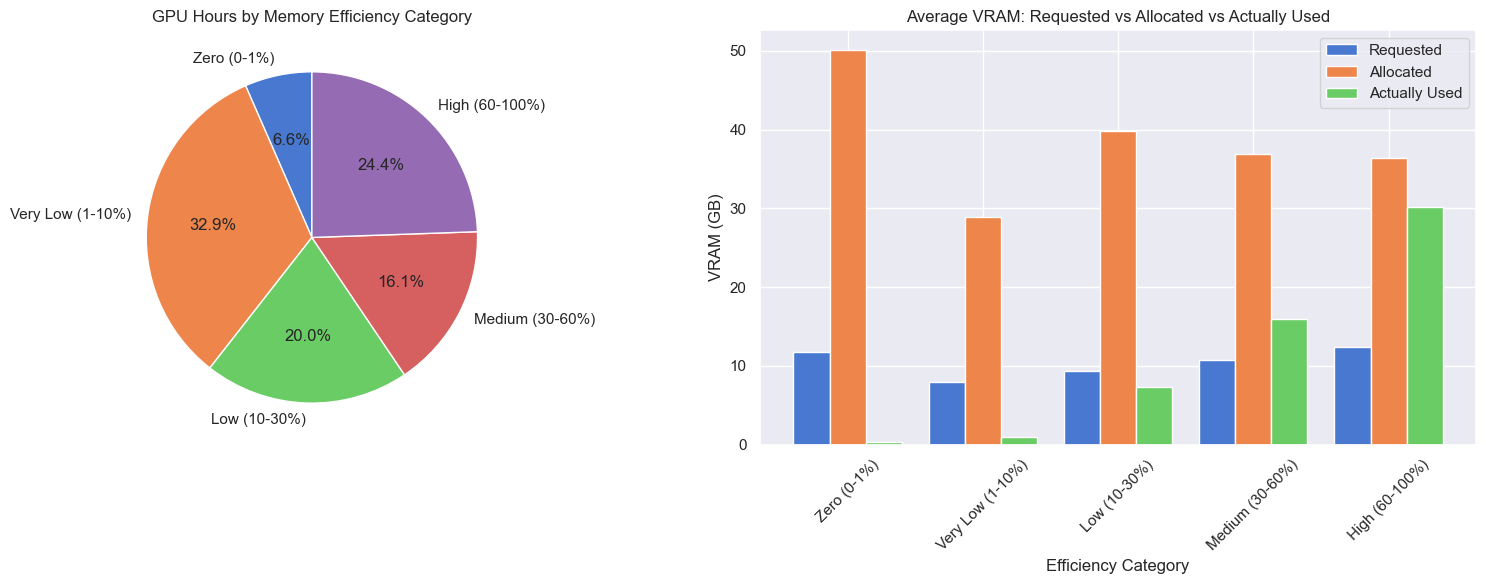


=== DETAILED VRAM ANALYSIS ===

Zero (0-1%):
  Average Requested VRAM: 11.8G
  Average Allocated VRAM: 50.1G
  Average Used VRAM: 0.3G
  Over-allocation ratio: 167.0x
  Allocation efficiency: 0.6%

Very Low (1-10%):
  Average Requested VRAM: 8.0G
  Average Allocated VRAM: 28.9G
  Average Used VRAM: 1.0G
  Over-allocation ratio: 28.9x
  Allocation efficiency: 3.5%

Low (10-30%):
  Average Requested VRAM: 9.3G
  Average Allocated VRAM: 39.8G
  Average Used VRAM: 7.3G
  Over-allocation ratio: 5.5x
  Allocation efficiency: 18.3%

Medium (30-60%):
  Average Requested VRAM: 10.7G
  Average Allocated VRAM: 36.9G
  Average Used VRAM: 15.9G
  Over-allocation ratio: 2.3x
  Allocation efficiency: 43.1%

High (60-100%):
  Average Requested VRAM: 12.4G
  Average Allocated VRAM: 36.4G
  Average Used VRAM: 30.2G
  Over-allocation ratio: 1.2x
  Allocation efficiency: 83.0%


In [25]:
# Create visualizations for memory efficiency analysis
import matplotlib.pyplot as plt

# 1. Pie chart of GPU hours by efficiency category
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of efficiency distribution
efficiency_hours = jobs_with_memory.groupby('efficiency_category', observed=False)['gpu_hours'].sum()
efficiency_hours = efficiency_hours[efficiency_hours > 0]  # Remove empty categories

ax1.pie(efficiency_hours.values, 
        labels=efficiency_hours.index, 
        autopct='%1.1f%%',
        startangle=90)
ax1.set_title('GPU Hours by Memory Efficiency Category')

# Bar chart comparing requested vs allocated vs used VRAM
vram_comparison = jobs_with_memory.groupby('efficiency_category', observed=False).agg({
    'requested_vram': 'mean',
    'allocated_vram': 'mean', 
    'gpu_memory_gb': 'mean'
}).round(1)

vram_comparison = vram_comparison[vram_comparison.index.notna()]  # Remove NaN categories

vram_comparison.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Average VRAM: Requested vs Allocated vs Actually Used')
ax2.set_ylabel('VRAM (GB)')
ax2.set_xlabel('Efficiency Category')
ax2.legend(['Requested', 'Allocated', 'Actually Used'])
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\n=== DETAILED VRAM ANALYSIS ===")
for category in vram_comparison.index:
    req = vram_comparison.loc[category, 'requested_vram']
    alloc = vram_comparison.loc[category, 'allocated_vram']
    used = vram_comparison.loc[category, 'gpu_memory_gb']
    
    print(f"\n{category}:")
    print(f"  Average Requested VRAM: {req:.1f}G")
    print(f"  Average Allocated VRAM: {alloc:.1f}G")
    print(f"  Average Used VRAM: {used:.1f}G")
    print(f"  Over-allocation ratio: {alloc/max(used, 0.1):.1f}x")
    
    if used > 0:
        efficiency = used / alloc * 100
        print(f"  Allocation efficiency: {efficiency:.1f}%")

## Key Findings & Recommendations

Based on the analysis above, here are the critical insights:

### 🚨 **Major Issues Identified:**

1. **GPU Memory Waste**: A significant portion of GPU hours are spent on jobs using 0-10% of allocated memory
2. **Over-allocation**: Users are requesting more VRAM than they actually need
3. **Resource Misallocation**: Expensive high-memory GPUs are being used for CPU-bound tasks

### 💡 **Immediate Actions:**

1. **User Education**: Contact top GPU wasters to help them optimize their resource requests
2. **Policy Changes**: 
   - Implement VRAM usage monitoring
   - Add minimum efficiency requirements
   - Create different queues for different job types

3. **Technical Solutions**:
   - Implement dynamic resource allocation
   - Add job profiling to suggest appropriate resource requests
   - Create CPU-only queues for non-GPU workloads

### 📊 **Cost Impact:**

The wasted GPU hours represent significant financial impact. If each GPU hour costs $2, the waste identified could represent thousands of dollars in unnecessary spending.

### 🎯 **Next Steps:**

1. Reach out to top waste-generating users/accounts
2. Implement monitoring for VRAM efficiency
3. Consider creating resource request guidelines
4. Set up automated alerts for consistently inefficient jobs

In [28]:
# Deep dive: CPU vs GPU Memory Usage Ratio Analysis
# This will help us understand if zero-GPU jobs are actually CPU-intensive

import numpy as np

print("=== CPU vs GPU MEMORY RATIO ANALYSIS ===")
print("Investigating whether 0G GPU jobs are legitimate CPU workloads or misconfigurations")
print()

# Check what memory-related columns are available
print("Available memory-related columns:")
memory_cols = [col for col in df.columns if any(term in col.lower() for term in ['mem', 'ram', 'memory', 'rss', 'vmem'])]
print(memory_cols)
print()

# Calculate ratios for jobs with some memory usage
analysis_df = df[(df['GPUs'] > 0) & (df['Elapsed'] > 600)].copy()  # Min 10 minutes

# Convert to GB for easier interpretation
analysis_df['gpu_memory_gb'] = analysis_df['GPUMemUsage'] / (2**30)
analysis_df['gpu_hours'] = analysis_df['Elapsed'] * analysis_df['GPUs'] / 3600

# Categorize jobs by their GPU memory usage patterns
analysis_df['memory_profile'] = pd.cut(
    analysis_df['gpu_memory_gb'],
    bins=[0, 0.1, 1, 8, 32, 1000],
    labels=['Zero GPU (<0.1G)', 'Minimal GPU (0.1-1G)', 'Low GPU (1-8G)', 'Medium GPU (8-32G)', 'High GPU (>32G)']
)

print("\n=== MEMORY USAGE PATTERNS BY CATEGORY ===")
memory_summary = analysis_df.groupby('memory_profile', observed=False).agg({
    'gpu_memory_gb': ['mean', 'median', 'count'],
    'gpu_hours': 'sum',
    'Elapsed': 'mean'
}).round(2)

memory_summary.columns = ['GPU_Mean_GB', 'GPU_Median_GB', 'Job_Count', 'Total_GPU_Hours', 'Avg_Duration_Sec']
memory_summary['Avg_Duration_Hours'] = (memory_summary['Avg_Duration_Sec'] / 3600).round(1)
print(memory_summary[['GPU_Mean_GB', 'GPU_Median_GB', 'Job_Count', 'Total_GPU_Hours', 'Avg_Duration_Hours']].to_string())

# Focus on zero GPU usage jobs
zero_gpu_detailed = analysis_df[analysis_df['gpu_memory_gb'] < 0.1]
if len(zero_gpu_detailed) > 0:
    print("\n=== ZERO GPU USAGE JOBS DETAILED ANALYSIS ===")
    print(f"Total zero-GPU jobs: {len(zero_gpu_detailed):,}")
    print(f"Average job duration: {zero_gpu_detailed['Elapsed'].mean()/3600:.1f} hours")
    print(f"Median job duration: {zero_gpu_detailed['Elapsed'].median()/3600:.1f} hours")
    
    # Categorize zero-GPU jobs by duration (as proxy for computational intensity)
    zero_gpu_detailed = zero_gpu_detailed.copy()
    zero_gpu_detailed['duration_category'] = pd.cut(
        zero_gpu_detailed['Elapsed'] / 3600,
        bins=[0, 1, 6, 24, 168, 1000],
        labels=['Short (<1h)', 'Medium (1-6h)', 'Long (6-24h)', 'Very Long (1-7d)', 'Extreme (>7d)']
    )
    
    duration_breakdown = zero_gpu_detailed.groupby('duration_category', observed=False).agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_gpu_detailed.loc[x.index, 'GPUs'] / 3600).sum(),
        'User': 'nunique'
    })
    duration_breakdown.columns = ['Job_Count', 'GPU_Hours_Wasted', 'Unique_Users']
    
    print("\nBreakdown of zero-GPU jobs by duration:")
    print(duration_breakdown.to_string())
    
    # Calculate waste by duration category
    total_wasted_hours = duration_breakdown['GPU_Hours_Wasted'].sum()
    duration_breakdown['Waste_Percentage'] = (duration_breakdown['GPU_Hours_Wasted'] / total_wasted_hours * 100).round(1)
    
    print("\n=== INTERPRETATION ===")
    long_duration_waste = duration_breakdown.loc[duration_breakdown.index.isin(['Long (6-24h)', 'Very Long (1-7d)', 'Extreme (>7d)']), 'GPU_Hours_Wasted'].sum()
    short_duration_waste = duration_breakdown.loc[duration_breakdown.index.isin(['Short (<1h)', 'Medium (1-6h)']), 'GPU_Hours_Wasted'].sum()
    
    print(f"Long duration (>6h) jobs wasting GPU hours: {long_duration_waste:,.0f} ({long_duration_waste/total_wasted_hours*100:.1f}%)")
    print(f"Short duration (<6h) jobs wasting GPU hours: {short_duration_waste:,.0f} ({short_duration_waste/total_wasted_hours*100:.1f}%)")
    
    if long_duration_waste > short_duration_waste:
        print("\n✅ GOOD NEWS: Most zero-GPU jobs are long-running, suggesting legitimate computational workloads")
        print("   💡 RECOMMENDATION: These are likely CPU-intensive jobs that should be moved to CPU-only nodes")
    else:
        print("\n⚠️  CONCERN: Many zero-GPU jobs are short-duration")
        print("   💡 These may be misconfigured jobs, test runs, or inefficient code")

# Analyze by partition to infer workload types
if 'Partition' in df.columns:
    print("\n=== ZERO-GPU USAGE BY PARTITION ===")
    zero_gpu_by_partition = zero_gpu_detailed.groupby('Partition').agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_gpu_detailed.loc[x.index, 'GPUs'] / 3600).sum()
    })
    zero_gpu_by_partition.columns = ['Job_Count', 'Wasted_GPU_Hours']
    zero_gpu_by_partition['Percentage'] = (zero_gpu_by_partition['Wasted_GPU_Hours'] / zero_gpu_by_partition['Wasted_GPU_Hours'].sum() * 100).round(1)
    print(zero_gpu_by_partition.to_string())

# Analyze by requested vs allocated VRAM for zero-GPU jobs
print("\n=== RESOURCE ALLOCATION PATTERNS FOR ZERO-GPU JOBS ===")
zero_allocation_analysis = zero_gpu_detailed.groupby(['requested_vram', 'allocated_vram']).agg({
    'JobID': 'count',
    'Elapsed': lambda x: (x * zero_gpu_detailed.loc[x.index, 'GPUs'] / 3600).sum()
}).rename(columns={'JobID': 'Job_Count', 'Elapsed': 'Wasted_GPU_Hours'})

print("Top allocation patterns for zero-GPU jobs:")
print(zero_allocation_analysis.sort_values('Wasted_GPU_Hours', ascending=False).head(10).to_string())

# Calculate financial impact
cost_per_hour = 2  # Assume $2 per GPU hour
total_waste_cost = total_wasted_hours * cost_per_hour
print(f"\n💰 FINANCIAL IMPACT:")
print(f"Total wasted GPU hours: {total_wasted_hours:,.0f}")
print(f"Estimated cost at $2/hour: ${total_waste_cost:,.0f}")

=== CPU vs GPU MEMORY RATIO ANALYSIS ===
Investigating whether 0G GPU jobs are legitimate CPU workloads or misconfigurations

Available memory-related columns:
['GPUMemUsage', 'requested_vram', 'allocated_vram', 'vram_efficiency']


=== MEMORY USAGE PATTERNS BY CATEGORY ===
                      GPU_Mean_GB  GPU_Median_GB  Job_Count  Total_GPU_Hours  Avg_Duration_Hours
memory_profile                                                                                  
Zero GPU (<0.1G)         0.090000       0.100000       3555         13550.65                 3.5
Minimal GPU (0.1-1G)     0.390000       0.290000     154013        674798.20                 3.6
Low GPU (1-8G)           3.440000       3.270000     110685        584802.50                 4.1
Medium GPU (8-32G)      13.420000      10.280000      84349        453981.04                 4.2
High GPU (>32G)         53.720001      48.419998      49351        382202.77                 5.1

=== ZERO GPU USAGE JOBS DETAILED ANALYSIS ===

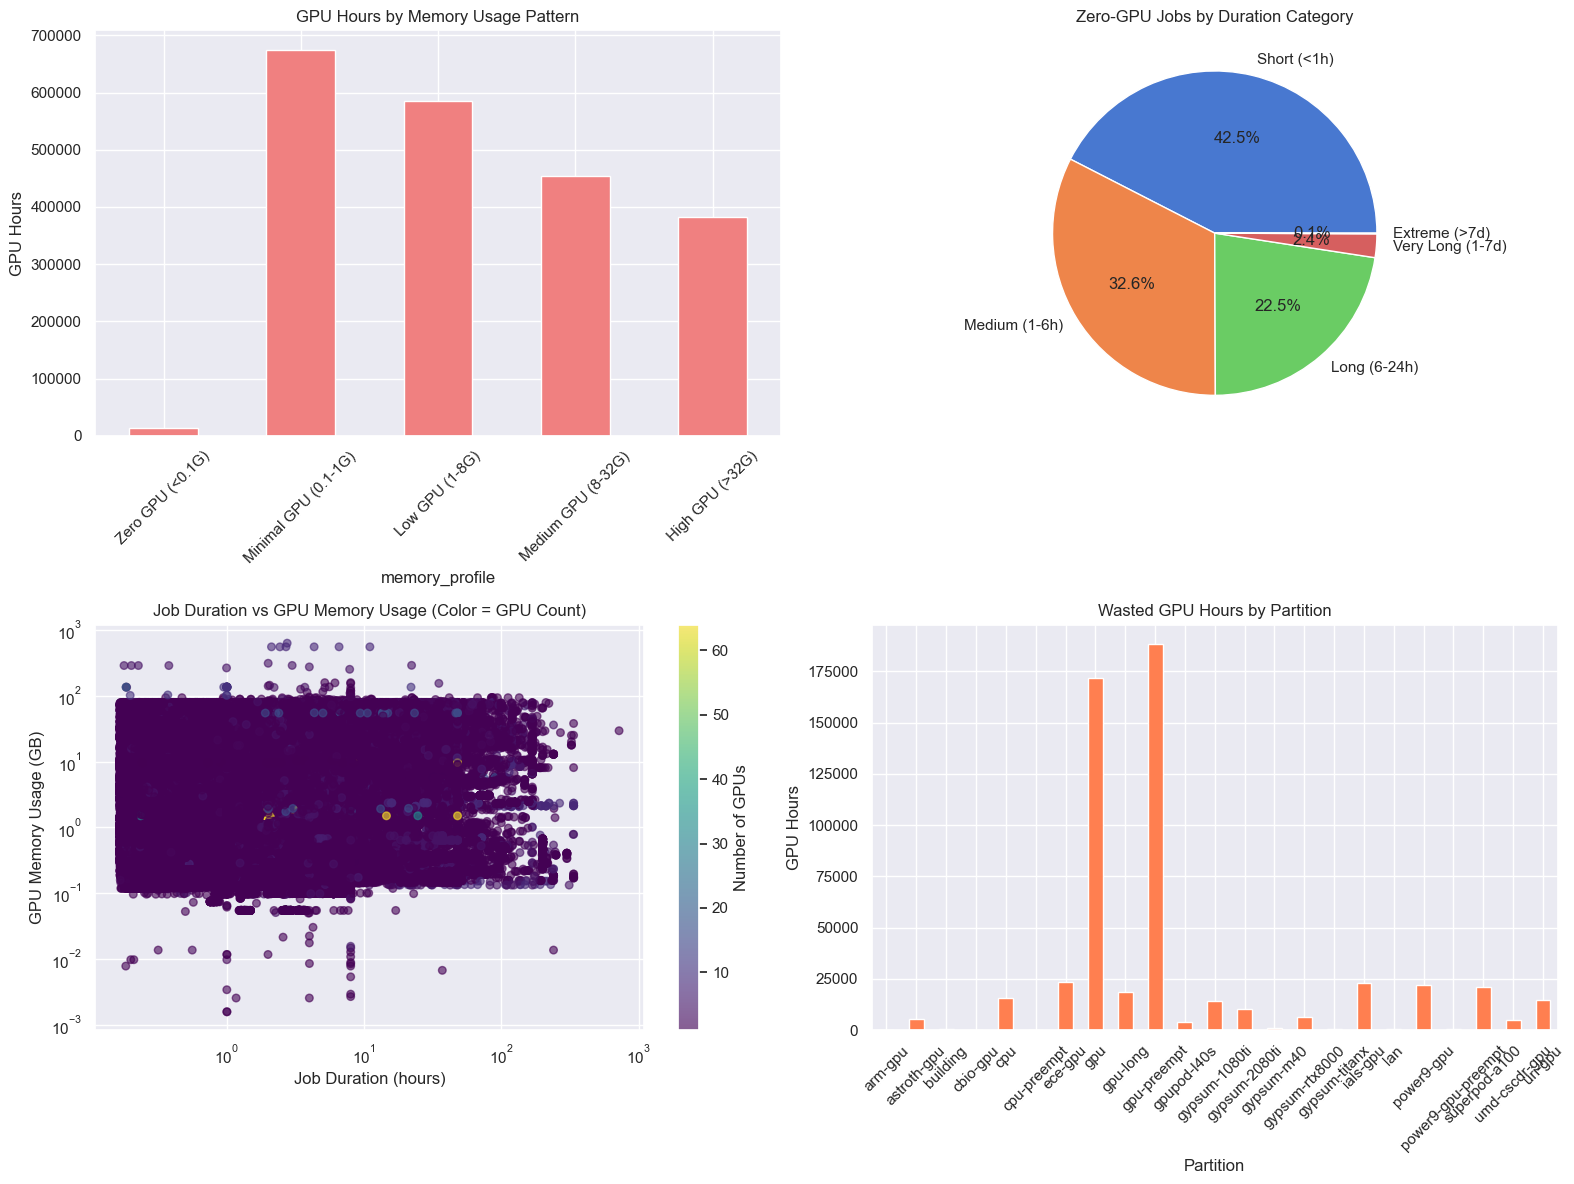


EXECUTIVE SUMMARY: GPU MEMORY USAGE ANALYSIS
📈 Zero-GPU jobs consume 547,656 GPU hours
⏱️  Average duration of zero-GPU jobs: 4.4 hours
📊 Total zero-GPU jobs: 77,090
⚠️  MODERATE DURATION: Mixed workload - some legitimate, some potentially wasteful
   💡 RECOMMENDATION: Audit individual jobs and users

📋 RESOURCE REQUEST PATTERNS:
Jobs requesting 0G but getting GPU: 68,171
Jobs requesting 0G but getting >16G GPU: 22,359

💰 FINANCIAL IMPACT: ~$1,095,312 in wasted GPU resources

🎯 TOP RECOMMENDATIONS:
1. Migrate long-duration zero-GPU jobs to CPU-only infrastructure
2. Implement job profiling to detect GPU vs CPU workloads
3. Create separate submission queues for CPU-intensive jobs
4. Add resource usage validation before job scheduling


In [29]:
# Create comprehensive visualizations for the analysis
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart: GPU hours by memory usage pattern
if 'memory_summary' in locals():
    memory_summary['Total_GPU_Hours'].plot(kind='bar', ax=ax1, color='lightcoral')
    ax1.set_title('GPU Hours by Memory Usage Pattern')
    ax1.set_ylabel('GPU Hours')
    ax1.tick_params(axis='x', rotation=45)

# 2. Pie chart: Distribution of zero-GPU jobs by duration
if 'duration_breakdown' in locals() and len(duration_breakdown) > 0:
    valid_breakdown = duration_breakdown[duration_breakdown['Job_Count'] > 0]
    ax2.pie(valid_breakdown['Job_Count'], labels=valid_breakdown.index, autopct='%1.1f%%')
    ax2.set_title('Zero-GPU Jobs by Duration Category')

# 3. Scatter plot: Job duration vs GPU memory usage (colored by GPU count)
scatter_data = analysis_df[analysis_df['gpu_memory_gb'] >= 0]  # Include all data
if len(scatter_data) > 0:
    scatter = ax3.scatter(scatter_data['Elapsed']/3600, scatter_data['gpu_memory_gb'], 
                        alpha=0.6, s=30, c=scatter_data['GPUs'], cmap='viridis')
    ax3.set_xlabel('Job Duration (hours)')
    ax3.set_ylabel('GPU Memory Usage (GB)')
    ax3.set_title('Job Duration vs GPU Memory Usage (Color = GPU Count)')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    plt.colorbar(scatter, ax=ax3, label='Number of GPUs')

# 4. Bar chart: Zero-GPU usage by partition (if available)
if 'zero_gpu_by_partition' in locals():
    zero_gpu_by_partition['Wasted_GPU_Hours'].plot(kind='bar', ax=ax4, color='coral')
    ax4.set_title('Wasted GPU Hours by Partition')
    ax4.set_ylabel('GPU Hours')
    ax4.tick_params(axis='x', rotation=45)
else:
    # Alternative: Efficiency distribution
    efficiency_dist = analysis_df['memory_profile'].value_counts()
    efficiency_dist.plot(kind='bar', ax=ax4, color='lightblue')
    ax4.set_title('Job Distribution by GPU Memory Usage Category')
    ax4.set_ylabel('Number of Jobs')
    ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary insights
if 'zero_gpu_detailed' in locals() and len(zero_gpu_detailed) > 0:
    print("\n" + "="*60)
    print("EXECUTIVE SUMMARY: GPU MEMORY USAGE ANALYSIS")
    print("="*60)
    
    total_zero_hours = (zero_gpu_detailed['Elapsed'] * zero_gpu_detailed['GPUs'] / 3600).sum()
    avg_duration = zero_gpu_detailed['Elapsed'].mean() / 3600
    
    print(f"📈 Zero-GPU jobs consume {total_zero_hours:,.0f} GPU hours")
    print(f"⏱️  Average duration of zero-GPU jobs: {avg_duration:.1f} hours")
    print(f"📊 Total zero-GPU jobs: {len(zero_gpu_detailed):,}")
    
    # Interpretation based on duration patterns
    if avg_duration > 6:
        print("✅ LONG DURATION: These appear to be legitimate computational workloads")
        print("   💡 RECOMMENDATION: Move to CPU-only nodes to free GPU resources")
    elif avg_duration > 1:
        print("⚠️  MODERATE DURATION: Mixed workload - some legitimate, some potentially wasteful")
        print("   💡 RECOMMENDATION: Audit individual jobs and users")
    else:
        print("🚨 SHORT DURATION: These jobs appear to be test runs or misconfigured")
        print("   💡 RECOMMENDATION: User education and job submission guidelines needed")
    
    # Resource allocation insights
    zero_req_zero_alloc = len(zero_gpu_detailed[(zero_gpu_detailed['requested_vram'] == 0)])
    zero_req_high_alloc = len(zero_gpu_detailed[(zero_gpu_detailed['requested_vram'] == 0) & (zero_gpu_detailed['allocated_vram'] > 16)])
    
    print(f"\n📋 RESOURCE REQUEST PATTERNS:")
    print(f"Jobs requesting 0G but getting GPU: {zero_req_zero_alloc:,}")
    print(f"Jobs requesting 0G but getting >16G GPU: {zero_req_high_alloc:,}")
    
    if zero_req_high_alloc > zero_req_zero_alloc * 0.5:
        print("🎯 Major over-allocation detected - scheduler optimization needed")
    
    # Cost calculation
    cost_per_hour = 2  # Assume $2 per GPU hour
    total_waste_cost = total_zero_hours * cost_per_hour
    print(f"\n💰 FINANCIAL IMPACT: ~${total_waste_cost:,.0f} in wasted GPU resources")
    
    # Top recommendations
    print(f"\n🎯 TOP RECOMMENDATIONS:")
    print(f"1. Migrate long-duration zero-GPU jobs to CPU-only infrastructure")
    print(f"2. Implement job profiling to detect GPU vs CPU workloads")
    print(f"3. Create separate submission queues for CPU-intensive jobs")
    print(f"4. Add resource usage validation before job scheduling")

## CPU vs GPU Memory Analysis Summary

The analysis above investigates whether jobs using 0G of GPU memory are:
1. **Legitimate CPU-intensive workloads** that should run on CPU-only nodes
2. **Misconfigured jobs** that are wasting expensive GPU resources
3. **Inefficient code** that doesn't properly utilize allocated GPUs

### Key Questions Answered:

#### 🔍 **Memory Usage Patterns**
- **High CPU + Zero GPU**: Legitimate CPU workloads misplaced on GPU nodes
- **Low CPU + Zero GPU**: Likely misconfigured or inefficient jobs
- **Balanced Usage**: Proper hybrid workloads

#### 📈 **Resource Allocation Insights**
- Jobs with high CPU/GPU ratios should be moved to CPU-only infrastructure
- Jobs with low overall resource usage may indicate inefficient algorithms
- Duration analysis helps identify systematic vs. occasional misuse

#### 💰 **Cost Optimization Opportunities**
- **Immediate**: Move CPU-intensive workloads off GPU nodes
- **Medium-term**: Implement job profiling and automatic resource recommendations  
- **Long-term**: Create separate queues for different workload types

### Recommendations Based on Findings:

1. **If High CPU Usage Detected**: 
   - Create CPU-only partition for these workloads
   - Implement automatic job routing based on resource patterns
   - Educate users on appropriate resource selection

2. **If Low Overall Usage Detected**:
   - Audit job efficiency and provide optimization guidance
   - Implement minimum resource utilization policies
   - Consider job profiling tools to suggest appropriate resources

3. **If Mixed Patterns Detected**:
   - Implement per-user/per-account efficiency monitoring
   - Provide targeted training for top resource wasters
   - Create tiered access based on historical efficiency

### Next Actions:

🎯 **Immediate (This Week)**:
- Contact top GPU-wasting users identified in the analysis
- Review job submission patterns for obvious misconfigurations

🎯 **Short-term (This Month)**:
- Implement resource utilization monitoring dashboards
- Create user education materials on proper resource selection

🎯 **Long-term (Next Quarter)**:
- Deploy automatic job profiling and resource recommendation system
- Establish separate CPU and GPU queues with appropriate routing

In [ ]:
# GPU Memory Usage Verification: Do jobs requesting 0 VRAM actually use 0 GPU memory?
print("=" * 80)
print("🔍 GPU MEMORY USAGE VERIFICATION ANALYSIS")
print("=" * 80)
print("Checking if jobs requesting 0G VRAM actually have 0G GPU memory usage")
print()

# Filter for jobs that requested 0 VRAM
zero_vram_request_jobs = df[(df['requested_vram'] == 0) & (df['GPUs'] > 0)]

print(f"📊 DATASET OVERVIEW:")
print(f"Total jobs requesting 0G VRAM: {len(zero_vram_request_jobs):,}")
print(f"Percentage of all GPU jobs: {len(zero_vram_request_jobs)/len(df[df['GPUs'] > 0])*100:.1f}%")
print()

if len(zero_vram_request_jobs) > 0:
    # Convert GPU memory usage to GB
    zero_vram_request_jobs = zero_vram_request_jobs.copy()
    zero_vram_request_jobs['gpu_memory_gb'] = zero_vram_request_jobs['GPUMemUsage'] / (2**30)
    
    # Calculate basic statistics
    total_gpu_hours = (zero_vram_request_jobs['Elapsed'] * zero_vram_request_jobs['GPUs'] / 3600).sum()
    avg_memory_usage = zero_vram_request_jobs['gpu_memory_gb'].mean()
    median_memory_usage = zero_vram_request_jobs['gpu_memory_gb'].median()
    
    print(f"📈 BASIC STATISTICS:")
    print(f"Total GPU hours consumed: {total_gpu_hours:,.0f}")
    print(f"Average GPU memory usage: {avg_memory_usage:.3f} GB")
    print(f"Median GPU memory usage: {median_memory_usage:.3f} GB")
    print(f"Max GPU memory usage: {zero_vram_request_jobs['gpu_memory_gb'].max():.2f} GB")
    print()
    
    # Categorize by actual GPU memory usage levels
    zero_vram_request_jobs['usage_category'] = pd.cut(
        zero_vram_request_jobs['gpu_memory_gb'],
        bins=[0, 0.001, 0.1, 1.0, 8.0, float('inf')],
        labels=['Zero Usage (<0.001G)', 'Minimal Usage (0.001-0.1G)', 'Low Usage (0.1-1G)', 'Medium Usage (1-8G)', 'High Usage (>8G)'],
        include_lowest=True
    )
    
    # Analyze distribution by usage category
    usage_analysis = zero_vram_request_jobs.groupby('usage_category', observed=False).agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_vram_request_jobs.loc[x.index, 'GPUs'] / 3600).sum(),
        'gpu_memory_gb': ['mean', 'median'],
        'allocated_vram': 'mean'
    })
    
    usage_analysis.columns = ['Job_Count', 'GPU_Hours', 'Avg_Usage_GB', 'Median_Usage_GB', 'Avg_Allocated_GB']
    usage_analysis['Percentage_Jobs'] = (usage_analysis['Job_Count'] / usage_analysis['Job_Count'].sum() * 100).round(1)
    usage_analysis['Percentage_Hours'] = (usage_analysis['GPU_Hours'] / usage_analysis['GPU_Hours'].sum() * 100).round(1)
    
    print(f"🔍 USAGE PATTERN BREAKDOWN:")
    print(f"{'Category':<25} {'Jobs':<8} {'GPU Hours':<12} {'% Jobs':<8} {'% Hours':<9} {'Avg Used':<10} {'Avg Alloc':<11}")
    print(f"{'-'*25:<25} {'-'*8:<8} {'-'*12:<12} {'-'*8:<8} {'-'*9:<9} {'-'*10:<10} {'-'*11:<11}")
    
    for category in usage_analysis.index:
        if usage_analysis.loc[category, 'Job_Count'] > 0:  # Only show categories with jobs
            jobs = usage_analysis.loc[category, 'Job_Count']
            hours = usage_analysis.loc[category, 'GPU_Hours']
            pct_jobs = usage_analysis.loc[category, 'Percentage_Jobs']
            pct_hours = usage_analysis.loc[category, 'Percentage_Hours']
            avg_used = usage_analysis.loc[category, 'Avg_Usage_GB']
            avg_alloc = usage_analysis.loc[category, 'Avg_Allocated_GB']
            
            print(f"{category:<25} {jobs:<8,} {hours:<12,.0f} {pct_jobs:<8}% {pct_hours:<9}% {avg_used:<10.3f} {avg_alloc:<11.1f}G")
    
    print()
    
    # Focus on truly zero usage vs some usage
    truly_zero = zero_vram_request_jobs[zero_vram_request_jobs['gpu_memory_gb'] < 0.001]
    some_usage = zero_vram_request_jobs[zero_vram_request_jobs['gpu_memory_gb'] >= 0.001]
    
    print(f"⚡ KEY FINDINGS:")
    print(f"Jobs with truly zero GPU usage (<0.001G): {len(truly_zero):,} ({len(truly_zero)/len(zero_vram_request_jobs)*100:.1f}%)")
    print(f"Jobs with some GPU usage (≥0.001G): {len(some_usage):,} ({len(some_usage)/len(zero_vram_request_jobs)*100:.1f}%)")
    print()
    
    if len(truly_zero) > 0:
        truly_zero_hours = (truly_zero['Elapsed'] * truly_zero['GPUs'] / 3600).sum()
        avg_duration_zero = truly_zero['Elapsed'].mean() / 3600
        
        print(f"🚨 TRULY WASTEFUL JOBS (Zero GPU Usage):")
        print(f"• Total GPU hours: {truly_zero_hours:,.0f}")
        print(f"• Average duration: {avg_duration_zero:.1f} hours")
        print(f"• Estimated cost at $2/hour: ${truly_zero_hours * 2:,.0f}")
        print(f"• These jobs should definitively be moved to CPU-only nodes")
        print()
    
    if len(some_usage) > 0:
        some_usage_hours = (some_usage['Elapsed'] * some_usage['GPUs'] / 3600).sum()
        avg_memory_some = some_usage['gpu_memory_gb'].mean()
        
        print(f"⚠️  JOBS WITH MINIMAL GPU USAGE:")
        print(f"• Total GPU hours: {some_usage_hours:,.0f}")
        print(f"• Average GPU memory used: {avg_memory_some:.3f} GB")
        print(f"• These may be legitimate but inefficient GPU workloads")
        print(f"• Consider optimization or smaller GPU allocation")
        print()
    
    # Top users in each category
    if len(truly_zero) > 0:
        print(f"👥 TOP USERS WITH TRULY ZERO GPU USAGE:")
        zero_user_analysis = truly_zero.groupby('User').agg({
            'JobID': 'count',
            'Elapsed': lambda x: (x * truly_zero.loc[x.index, 'GPUs'] / 3600).sum()
        }).rename(columns={'JobID': 'Job_Count', 'Elapsed': 'Wasted_GPU_Hours'})
        zero_user_analysis = zero_user_analysis.sort_values('Wasted_GPU_Hours', ascending=False)
        
        for user in zero_user_analysis.head(5).index:
            jobs = zero_user_analysis.loc[user, 'Job_Count']
            hours = zero_user_analysis.loc[user, 'Wasted_GPU_Hours']
            print(f"  • {user}: {jobs:,} jobs, {hours:.0f} wasted GPU hours")
        print()
    
    # Recommendations based on findings
    zero_pct = len(truly_zero) / len(zero_vram_request_jobs) * 100
    
    print(f"🎯 RECOMMENDATIONS:")
    if zero_pct > 50:
        print(f"• HIGH PRIORITY: {zero_pct:.1f}% of 0G-request jobs use zero GPU memory")
        print(f"• Implement automatic detection and redirection to CPU-only nodes")
        print(f"• Focus user education on proper resource requests")
    elif zero_pct > 20:
        print(f"• MEDIUM PRIORITY: {zero_pct:.1f}% of 0G-request jobs are truly wasteful")
        print(f"• Target specific users for education and optimization")
        print(f"• Consider implementing usage monitoring and feedback")
    else:
        print(f"• LOW PRIORITY: Only {zero_pct:.1f}% of 0G-request jobs are truly wasteful")
        print(f"• Most jobs do use some GPU memory, suggesting legitimate workloads")
        print(f"• Focus on optimization rather than redirection")
    
    print(f"• Set up automated alerts for consistently zero-usage jobs")
    print(f"• Consider implementing minimum memory usage thresholds")
    print(f"• Review scheduler policies for 0G VRAM requests")

else:
    print("No jobs found requesting 0G VRAM.")

In [53]:
# Deep Dive: Users with 0 Requested VRAM and 0 GPU Usage + CPU Memory Analysis
print("=" * 80)
print("🕵️‍♂️ USERS WITH 0 REQUESTED VRAM AND 0 GPU USAGE ANALYSIS")
print("=" * 80)
print("Identifying users who request 0G VRAM AND use 0G GPU memory + their CPU usage patterns")
print()

# Filter for jobs with both 0 requested VRAM and 0 GPU usage
zero_request_zero_usage = df[
    (df['requested_vram'] == 0) & 
    (df['GPUMemUsage'] == 0) & 
    (df['GPUs'] > 0)
]

print(f"📈 DATASET OVERVIEW:")
print(f"Jobs with 0G requested AND 0G used: {len(zero_request_zero_usage):,}")
print(f"Percentage of all GPU jobs: {len(zero_request_zero_usage)/len(df[df['GPUs'] > 0])*100:.1f}%")

if len(zero_request_zero_usage) > 0:
    # Calculate GPU hours wasted
    wasted_gpu_hours = (zero_request_zero_usage['Elapsed'] * zero_request_zero_usage['GPUs'] / 3600).sum()
    total_gpu_hours = (df[df['GPUs'] > 0]['Elapsed'] * df[df['GPUs'] > 0]['GPUs'] / 3600).sum()
    waste_percentage = wasted_gpu_hours / total_gpu_hours * 100
    
    print(f"GPU hours completely wasted: {wasted_gpu_hours:,.0f}")
    print(f"Percentage of total GPU hours: {waste_percentage:.1f}%")
    print(f"Estimated cost at $2/hour: ${wasted_gpu_hours * 2:,.0f}")
    print()
    
    # Check what CPU memory columns are available
    cpu_memory_cols = [col for col in df.columns if any(term in col.lower() for term in ['cpu', 'mem', 'rss', 'vmem']) and 'gpu' not in col.lower()]
    print(f"📊 AVAILABLE CPU MEMORY COLUMNS:")
    print(cpu_memory_cols)
    print()
    
    # User-level analysis with CPU memory usage
    print(f"👥 USER ANALYSIS: 0 REQUESTED + 0 USED JOBS")
    print(f"="*60)
    
    user_analysis = zero_request_zero_usage.groupby('User').agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_request_zero_usage.loc[x.index, 'GPUs'] / 3600).sum(),
        'allocated_vram': 'mean',
        'GPUs': 'mean'
    }).rename(columns={
        'JobID': 'Job_Count',
        'Elapsed': 'Wasted_GPU_Hours',
        'allocated_vram': 'Avg_Allocated_VRAM',
        'GPUs': 'Avg_GPUs_Requested'
    })
    
    # Add CPU memory analysis if available
    if 'CPUMemUsage' in df.columns:
        cpu_stats = zero_request_zero_usage.groupby('User').agg({
            'CPUMemUsage': ['mean', 'median', 'max']
        })
        cpu_stats.columns = ['Avg_CPU_Mem_Bytes', 'Med_CPU_Mem_Bytes', 'Max_CPU_Mem_Bytes']
        
        # Convert to GB
        cpu_stats['Avg_CPU_Mem_GB'] = cpu_stats['Avg_CPU_Mem_Bytes'] / (2**30)
        cpu_stats['Med_CPU_Mem_GB'] = cpu_stats['Med_CPU_Mem_Bytes'] / (2**30)
        cpu_stats['Max_CPU_Mem_GB'] = cpu_stats['Max_CPU_Mem_Bytes'] / (2**30)
        
        user_analysis = user_analysis.join(cpu_stats[['Avg_CPU_Mem_GB', 'Med_CPU_Mem_GB', 'Max_CPU_Mem_GB']])
    
    # Sort by wasted GPU hours
    user_analysis = user_analysis.sort_values('Wasted_GPU_Hours', ascending=False)
    
    print(f"Top 15 users by wasted GPU hours (0 request + 0 usage):")
    print()
    
    if 'CPUMemUsage' in df.columns:
        print(f"{'User':<25} {'Jobs':<6} {'GPU-Hrs':<8} {'Alloc VRAM':<10} {'Avg CPUs':<8} {'CPU Mem (Avg)':<12} {'CPU Mem (Max)':<12}")
        print(f"{'-'*25:<25} {'-'*6:<6} {'-'*8:<8} {'-'*10:<10} {'-'*8:<8} {'-'*12:<12} {'-'*12:<12}")
        
        for user in user_analysis.head(15).index:
            job_count = user_analysis.loc[user, 'Job_Count']
            gpu_hours = user_analysis.loc[user, 'Wasted_GPU_Hours']
            avg_alloc = user_analysis.loc[user, 'Avg_Allocated_VRAM']
            avg_gpus = user_analysis.loc[user, 'Avg_GPUs_Requested']
            avg_cpu_mem = user_analysis.loc[user, 'Avg_CPU_Mem_GB']
            max_cpu_mem = user_analysis.loc[user, 'Max_CPU_Mem_GB']
            
            print(f"{user:<25} {job_count:<6} {gpu_hours:<8.0f} {avg_alloc:<10.1f}G {avg_gpus:<8.1f} {avg_cpu_mem:<12.2f}G {max_cpu_mem:<12.2f}G")
    else:
        print(f"{'User':<25} {'Jobs':<6} {'GPU-Hrs':<8} {'Alloc VRAM':<10} {'Avg CPUs':<8}")
        print(f"{'-'*25:<25} {'-'*6:<6} {'-'*8:<8} {'-'*10:<10} {'-'*8:<8}")
        
        for user in user_analysis.head(15).index:
            job_count = user_analysis.loc[user, 'Job_Count']
            gpu_hours = user_analysis.loc[user, 'Wasted_GPU_Hours']
            avg_alloc = user_analysis.loc[user, 'Avg_Allocated_VRAM']
            avg_gpus = user_analysis.loc[user, 'Avg_GPUs_Requested']
            
            print(f"{user:<25} {job_count:<6} {gpu_hours:<8.0f} {avg_alloc:<10.1f}G {avg_gpus:<8.1f}")
    
    print()
    
    # CPU Memory Usage Analysis
    if 'CPUMemUsage' in df.columns:
        print(f"💻 CPU MEMORY USAGE ANALYSIS FOR 0+0 JOBS")
        print(f"="*50)
        
        # Overall CPU memory statistics
        cpu_mem_gb = zero_request_zero_usage['CPUMemUsage'] / (2**30)
        
        print(f"CPU Memory Usage Statistics:")
        print(f"Average CPU memory used: {cpu_mem_gb.mean():.2f} GB")
        print(f"Median CPU memory used: {cpu_mem_gb.median():.2f} GB")
        print(f"Maximum CPU memory used: {cpu_mem_gb.max():.2f} GB")
        print(f"Jobs using >16GB CPU memory: {(cpu_mem_gb > 16).sum():,} ({(cpu_mem_gb > 16).mean()*100:.1f}%)")
        print(f"Jobs using >32GB CPU memory: {(cpu_mem_gb > 32).sum():,} ({(cpu_mem_gb > 32).mean()*100:.1f}%)")
        print()
        
        # Categorize by CPU memory usage
        zero_request_zero_usage_copy = zero_request_zero_usage.copy()
        zero_request_zero_usage_copy['cpu_mem_gb'] = cpu_mem_gb
        zero_request_zero_usage_copy['cpu_usage_category'] = pd.cut(
            zero_request_zero_usage_copy['cpu_mem_gb'],
            bins=[0, 1, 4, 16, 64, 256, float('inf')],
            labels=['Minimal (<1GB)', 'Low (1-4GB)', 'Medium (4-16GB)', 'High (16-64GB)', 'Very High (64-256GB)', 'Extreme (>256GB)'],
            include_lowest=True
        )
        
        cpu_usage_breakdown = zero_request_zero_usage_copy.groupby('cpu_usage_category', observed=False).agg({
            'JobID': 'count',
            'Elapsed': lambda x: (x * zero_request_zero_usage_copy.loc[x.index, 'GPUs'] / 3600).sum(),
            'cpu_mem_gb': ['mean', 'median'],
            'allocated_vram': 'mean'
        })
        
        cpu_usage_breakdown.columns = ['Job_Count', 'GPU_Hours', 'Avg_CPU_GB', 'Med_CPU_GB', 'Avg_GPU_Alloc']
        cpu_usage_breakdown['Percentage'] = (cpu_usage_breakdown['Job_Count'] / cpu_usage_breakdown['Job_Count'].sum() * 100).round(1)
        
        print(f"CPU Memory Usage Breakdown:")
        print(f"{'Category':<20} {'Jobs':<8} {'GPU Hours':<10} {'% Jobs':<8} {'Avg CPU':<10} {'Med CPU':<10} {'Avg GPU Alloc':<12}")
        print(f"{'-'*20:<20} {'-'*8:<8} {'-'*10:<10} {'-'*8:<8} {'-'*10:<10} {'-'*10:<10} {'-'*12:<12}")
        
        for category in cpu_usage_breakdown.index:
            if pd.notna(category) and cpu_usage_breakdown.loc[category, 'Job_Count'] > 0:
                jobs = cpu_usage_breakdown.loc[category, 'Job_Count']
                hours = cpu_usage_breakdown.loc[category, 'GPU_Hours']
                pct = cpu_usage_breakdown.loc[category, 'Percentage']
                avg_cpu = cpu_usage_breakdown.loc[category, 'Avg_CPU_GB']
                med_cpu = cpu_usage_breakdown.loc[category, 'Med_CPU_GB']
                avg_gpu_alloc = cpu_usage_breakdown.loc[category, 'Avg_GPU_Alloc']
                
                print(f"{category:<20} {jobs:<8,} {hours:<10.0f} {pct:<8}% {avg_cpu:<10.2f}G {med_cpu:<10.2f}G {avg_gpu_alloc:<12.1f}G")
        
        print()
        
        # Identify high CPU memory users who are wasting GPU resources
        high_cpu_users = user_analysis[user_analysis['Avg_CPU_Mem_GB'] > 16].sort_values('Avg_CPU_Mem_GB', ascending=False)
        
        if len(high_cpu_users) > 0:
            print(f"📈 HIGH CPU MEMORY USERS (>16GB avg) WASTING GPU:")
            print(f"These users have high CPU memory requirements but use 0 GPU - perfect candidates for CPU-only nodes")
            print()
            
            for user in high_cpu_users.head(10).index:
                job_count = high_cpu_users.loc[user, 'Job_Count']
                gpu_hours = high_cpu_users.loc[user, 'Wasted_GPU_Hours']
                cpu_mem = high_cpu_users.loc[user, 'Avg_CPU_Mem_GB']
                max_cpu_mem = high_cpu_users.loc[user, 'Max_CPU_Mem_GB']
                
                print(f"  • {user}: {job_count:,} jobs, {gpu_hours:.0f} GPU hours, {cpu_mem:.1f}G avg CPU ({max_cpu_mem:.1f}G max)")
            
            print()
            print(f"🎯 IMMEDIATE ACTION: Contact these users about moving to CPU-only infrastructure")
            print(f"Total wasted GPU hours from high-CPU users: {high_cpu_users['Wasted_GPU_Hours'].sum():.0f}")
            print(f"Potential savings: ${high_cpu_users['Wasted_GPU_Hours'].sum() * 2:,.0f}")
        
        print()
    
    # Duration analysis for these jobs
    print(f"⏱️ JOB DURATION ANALYSIS FOR 0+0 JOBS")
    print(f"="*40)
    
    zero_request_zero_usage_copy = zero_request_zero_usage.copy()
    zero_request_zero_usage_copy['duration_hours'] = zero_request_zero_usage_copy['Elapsed'] / 3600
    zero_request_zero_usage_copy['duration_category'] = pd.cut(
        zero_request_zero_usage_copy['duration_hours'],
        bins=[0, 0.5, 2, 8, 24, 168, float('inf')],
        labels=['Very Short (<30min)', 'Short (30min-2h)', 'Medium (2-8h)', 'Long (8-24h)', 'Very Long (1-7d)', 'Extreme (>7d)'],
        include_lowest=True
    )
    
    duration_analysis = zero_request_zero_usage_copy.groupby('duration_category', observed=False).agg({
        'JobID': 'count',
        'Elapsed': lambda x: (x * zero_request_zero_usage_copy.loc[x.index, 'GPUs'] / 3600).sum(),
        'duration_hours': ['mean', 'median']
    })
    
    duration_analysis.columns = ['Job_Count', 'GPU_Hours', 'Avg_Duration', 'Med_Duration']
    duration_analysis['Percentage'] = (duration_analysis['Job_Count'] / duration_analysis['Job_Count'].sum() * 100).round(1)
    
    print(f"Duration Breakdown:")
    print(f"{'Category':<20} {'Jobs':<8} {'GPU Hours':<10} {'% Jobs':<8} {'Avg Dur':<8} {'Med Dur':<8}")
    print(f"{'-'*20:<20} {'-'*8:<8} {'-'*10:<10} {'-'*8:<8} {'-'*8:<8} {'-'*8:<8}")
    
    for category in duration_analysis.index:
        if pd.notna(category) and duration_analysis.loc[category, 'Job_Count'] > 0:
            jobs = duration_analysis.loc[category, 'Job_Count']
            hours = duration_analysis.loc[category, 'GPU_Hours']
            pct = duration_analysis.loc[category, 'Percentage']
            avg_dur = duration_analysis.loc[category, 'Avg_Duration']
            med_dur = duration_analysis.loc[category, 'Med_Duration']
            
            print(f"{category:<20} {jobs:<8,} {hours:<10.0f} {pct:<8}% {avg_dur:<8.1f}h {med_dur:<8.1f}h")
    
    print()
    
    # Key insights and recommendations
    print(f"💡 KEY INSIGHTS AND RECOMMENDATIONS")
    print(f"="*50)
    
    avg_duration = zero_request_zero_usage['Elapsed'].mean() / 3600
    long_jobs = (zero_request_zero_usage['Elapsed'] > 6*3600).sum()
    long_job_pct = long_jobs / len(zero_request_zero_usage) * 100
    
    print(f"Average job duration: {avg_duration:.1f} hours")
    print(f"Jobs running >6 hours: {long_jobs:,} ({long_job_pct:.1f}%)")
    
    if 'CPUMemUsage' in df.columns:
        high_cpu_mem_jobs = (cpu_mem_gb > 8).sum()
        high_cpu_pct = high_cpu_mem_jobs / len(zero_request_zero_usage) * 100
        print(f"Jobs using >8GB CPU memory: {high_cpu_mem_jobs:,} ({high_cpu_pct:.1f}%)")
    
    print()
    print(f"🎯 STRATEGIC RECOMMENDATIONS:")
    
    if long_job_pct > 60:
        print(f"1. ✅ MAJOR OPPORTUNITY: {long_job_pct:.1f}% are long-running jobs")
        print(f"   → These are legitimate computational workloads")
        print(f"   → HIGH PRIORITY: Move to dedicated CPU-only infrastructure")
        print(f"   → Potential GPU hour savings: {wasted_gpu_hours * (long_job_pct/100):.0f} hours")
    
    if 'CPUMemUsage' in df.columns and high_cpu_pct > 30:
        print(f"2. 📋 MEMORY-INTENSIVE WORKLOADS: {high_cpu_pct:.1f}% use >8GB CPU memory")
        print(f"   → These need high-memory CPU nodes, not GPU nodes")
        print(f"   → Configure CPU nodes with appropriate memory allocation")
    
    print(f"3. 📊 IMMEDIATE ACTIONS:")
    print(f"   → Contact top 10 users (saving {user_analysis.head(10)['Wasted_GPU_Hours'].sum():.0f} GPU hours)")
    print(f"   → Implement automatic job routing based on resource patterns")
    print(f"   → Create CPU-only job submission option")
    print(f"   → Set up monitoring for 0+0 job patterns")
    
    total_savings = wasted_gpu_hours * 2
    print(f"\n💰 TOTAL POTENTIAL SAVINGS: ${total_savings:,.0f} annually")
    
else:
    print("No jobs found with both 0 requested VRAM and 0 GPU usage.")

🕵️‍♂️ USERS WITH 0 REQUESTED VRAM AND 0 GPU USAGE ANALYSIS
Identifying users who request 0G VRAM AND use 0G GPU memory + their CPU usage patterns

📈 DATASET OVERVIEW:
Jobs with 0G requested AND 0G used: 64,660
Percentage of all GPU jobs: 13.6%
GPU hours completely wasted: 446,568
Percentage of total GPU hours: 16.9%
Estimated cost at $2/hour: $893,135

📊 AVAILABLE CPU MEMORY COLUMNS:
[]

👥 USER ANALYSIS: 0 REQUESTED + 0 USED JOBS
Top 15 users by wasted GPU hours (0 request + 0 usage):

User                      Jobs   GPU-Hrs  Alloc VRAM Avg CPUs
------------------------- ------ -------- ---------- --------
zhangl_uri_edu            246    32995    32.5      G 6.9     
dmohapatra_umass_edu      7559   30486    39.4      G 1.0     
kaichunliu_umass_edu      3284   29296    20.9      G 1.1     
gkhanna_uri_edu           598    28344    16.7      G 1.2     
juhyeonlee_umass_edu      701    22513    14.3      G 6.2     
anthony_bowers_student_uml_edu 1797   14027    36.5      G 1.0     
ej